# Random Search for Hyper-Parameter Optimization

**Authors:** James Bergstra, Yoshua Bengio (Université de Montréal)
**Venue:** Journal of Machine Learning Research 13 (2012), 281–305

---

## Abstract

The paper argues, empirically and theoretically, that randomly sampled trials are more efficient than grid search for hyper-parameter optimization. Random search is re-run against the grid-search and manual-search experiments of Larochelle et al. (2007) on single-layer neural networks and Deep Belief Networks (DBNs). For neural networks, random search matches or beats grid search at a small fraction of the computational cost. Given the same budget, it finds better models because it can explore a larger configuration space. For DBNs with up to 32 hyper-parameters, pure random search is competitive with expert-guided manual and grid search on most data sets. A Gaussian process analysis of the response surface explains why: only a few hyper-parameters matter for any given data set, and which ones matter varies across data sets. Random search is therefore proposed as the natural baseline against which adaptive hyper-parameter optimization methods should be judged.

---

## Problems

1. **Hyper-parameter optimization is an expensive outer-loop problem.** The goal is to choose hyper-parameters that minimize generalization error:

$$
\lambda^{(*)} = \arg\min_{\lambda \in \Lambda} \; \mathbb{E}_{x \sim \mathcal{G}_x}\left[ L\left(x; \mathcal{A}_\lambda(X^{(\text{train})})\right) \right]
$$

   In practice this is approximated with a validation set and a finite set of $$S$$ trials:

$$
\hat{\lambda} = \arg\min_{\lambda \in \{\lambda^{(1)}, \dots, \lambda^{(S)}\}} \Psi(\lambda), \qquad \Psi(\lambda) = \underset{x \in X^{(\text{valid})}}{\text{mean}} \; L\left(x; \mathcal{A}_\lambda(X^{(\text{train})})\right)
$$

   The critical design decision is how to choose the trial set $$\{\lambda^{(1)}, \dots, \lambda^{(S)}\}$$.

2. **Grid search suffers from the curse of dimensionality.** The number of trials grows exponentially with the number of hyper-parameters $$K$$:

$$
S = \prod_{k=1}^{K} \left| L^{(k)} \right|
$$

3. **Grid search wastes trials on irrelevant dimensions.** When the response function has low effective dimensionality, that is,

$$
f(x_1, x_2) \approx g(x_1),
$$

   a grid tests each important value many times while varying only unimportant ones. For example, a 3 × 3 grid evaluates the important dimension at only 3 distinct values.

4. **Manual search is hard to reproduce.** It depends on expert intuition, which limits both scientific reproducibility and use by non-experts.

5. **Reported test error is uncertain.** When many trials have nearly equal validation scores, the conventional practice of reporting the test score of the single best-validation model ignores the uncertainty in model selection.

---

## Proposed Solutions

- **Random search.** Draw trials i.i.d. from a distribution over the same configuration space a grid would span. Log-uniform ("geometric") sampling is used for scale-type hyper-parameters such as learning rates and layer sizes.
- **Uncertainty-aware generalization estimate.** Report a weighted average of test scores, where each trial is weighted by the probability that it is truly the best on validation.
- **Random experiment efficiency curve.** Because trials are i.i.d., one experiment of $$S$$ trials can be treated as $$N$$ independent experiments of size $$s$$, provided $$sN \le S$$. This gives the distribution of best-model performance as a function of budget.
- **Response-surface analysis.** Gaussian process regression with Automatic Relevance Determination (ARD) is fit to the trials to measure how sensitive $$\Psi$$ is to each hyper-parameter.

---

## Purpose

- Show that random search is more efficient than grid search, especially in high-dimensional search spaces.
- Explain this efficiency through the low effective dimensionality of $$\Psi$$.
- Compare random search against quasi-random (low-discrepancy) point sets and against expert-guided sequential manual search.
- Establish random search, rather than grid search, as the standard baseline for future adaptive hyper-parameter optimization algorithms.

---

## Methodology

### 1. Estimating Generalization Under Selection Uncertainty

Validation and test variances are computed for zero-one loss using Bernoulli variance:

$$
V^{(\text{valid})}(\lambda) = \frac{\Psi^{(\text{valid})}(\lambda)\left(1 - \Psi^{(\text{valid})}(\lambda)\right)}{|X^{(\text{valid})}| - 1}
$$

Each trial is weighted by the probability that it is the validation winner:

$$
w_s = P\left(Z^{(s)} < Z^{(s')}, \; \forall s' \neq s\right), \qquad Z^{(i)} \sim \mathcal{N}\left(\Psi^{(\text{valid})}(\lambda^{(i)}), \; V^{(\text{valid})}(\lambda^{(i)})\right)
$$

The best-model score $$z$$ is modeled as a Gaussian mixture with the following mean and variance:

$$
\mu_z = \sum_{s=1}^{S} w_s \mu_s, \qquad \sigma_z^2 = \sum_{s=1}^{S} w_s \left(\mu_s^2 + \sigma_s^2\right) - \mu_z^2
$$

The weights $$w_s$$ are estimated by Monte Carlo simulation; a few tens of draws are sufficient.

### 2. Data Sets

The eight classification benchmarks from Larochelle et al. (2007) are used. All images are 28 × 28.

| Data set | Task | Train / Valid / Test |
|---|---|---|
| mnist basic | Digit classification (10 classes) | 10,000 / 2,000 / 50,000 |
| mnist background images | Digits over natural-image patches | 10,000 / 2,000 / 50,000 |
| mnist background random | Digits over uniform noise | 10,000 / 2,000 / 50,000 |
| mnist rotated | Digits rotated by a random angle in $$[0, 2\pi]$$ | 10,000 / 2,000 / 50,000 |
| mnist rotated background images | Rotated digits over natural images | 10,000 / 2,000 / 50,000 |
| rectangles | Tall vs. wide rectangle outline | 1,000 / 200 / 50,000 |
| rectangles images | Tall vs. wide, natural-image textures | 10,000 / 2,000 / 50,000 |
| convex | Convex vs. non-convex white region | Not specified in the text |

### 3. Neural Network Search Space

The model is a single-hidden-layer network trained with SGD. The space has 7 hyper-parameters without preprocessing and 9 with preprocessing. Each experiment draws $$S = 256$$ trials.

| Hyper-parameter | Sampling distribution |
|---|---|
| Preprocessing | None, normalize, or PCA (equal probability); PCA keeps a variance fraction drawn from $$U(0.5, 1.0)$$ |
| Weight initialization | Uniform on $$(-1, 1)$$ or unit normal; scaled by a multiplier over $$\sqrt{\text{fan-in}}$$ or by the Glorot–Bengio heuristic |
| Hidden units | Geometric (log-uniform) from 18 to 1024 |
| Activation function | Sigmoid or tanh |
| Minibatch size | 20 or 100 |
| Initial learning rate $$\varepsilon_0$$ | Geometric from 0.001 to 10.0 |
| Annealing start $$t_0$$ | Geometric from 300 to 30,000 |
| $$\ell_2$$ penalty | Applied with probability 0.5; strength drawn exponentially from $$3.1 \times 10^{-7}$$ to $$3.1 \times 10^{-5}$$ |

The learning-rate schedule is:

$$
\varepsilon_t = \frac{t_0 \, \varepsilon_0}{\max(t, t_0)}
$$

Training runs for between 100 and 1,000 epochs, with early stopping if the best validation score occurred before iteration $$t/2$$.

The grid-search baseline from Larochelle et al. (2007) uses about 100 trials per data set on average and does not include preprocessing.

### 4. Gaussian Process / ARD Analysis

A Gaussian process with a product of per-dimension squared-exponential kernels is fit to $$\Psi(\lambda)$$:

$$
k(a, b) = \exp\left(-\left(\frac{a - b}{l}\right)^2\right), \qquad \text{relevance} = \frac{1}{l}
$$

- Hyper-parameters are rescaled to $$[0, 1]$$. Log-sampled hyper-parameters are analyzed on the log scale.
- Length scales are chosen to maximize the marginal likelihood.
- Each fit is repeated 50 times, each time on a random 80% subsample of trials and with random initialization, to account for local optima.

### 5. Simulation: Grid vs. Random vs. Low-Discrepancy Sets

The synthetic task is to find a randomly placed axis-aligned target occupying 1% of the unit hypercube. Four variants are tested: a cube or an elongated hyper-rectangle, each in 3 or 5 dimensions. The elongated targets have low effective dimensionality.

- 100 random search problems are generated.
- Experiment sizes range from 1 to 512 trials.
- Compared methods: grids with monotonic resolution, pseudo-random search, Latin hypercube sampling, and the Sobol sequence (representing Sobol, Halton, and Niederreiter).

The expected success rate of random search with $$T$$ trials is known in closed form:

$$
P(\text{hit}) = 1 - \left(1 - \frac{v}{V}\right)^T = 1 - 0.99^T
$$

### 6. Deep Belief Network Search Space

DBNs with 1, 2, or 3 layers are built from stacked RBMs trained with contrastive divergence. The space has 8 global and 8 per-layer hyper-parameters, for a total of 32 in the 3-layer case.

- **Per-layer hyper-parameters:** hidden units (log-uniform, 128 to 4,000), initialization distribution, multiplier and fan-out scaling, CD iterations (log-uniform, 1 to 10,000), binary sampling of inputs, CD learning rate (log-uniform, $$10^{-4}$$ to 1), and CD annealing start.
- **Global hyper-parameters:** raw pixels vs. ZCA preprocessing (with a variance fraction), random seed, fine-tuning learning rate (log-uniform, $$10^{-3}$$ to 10), fine-tuning annealing start, and $$\ell_2$$ penalty (0 with probability 0.5, else log-uniform $$10^{-7}$$ to $$10^{-4}$$).

A grid is infeasible here: even 2 values per dimension gives $$2^{32} > 10^9$$ trials.

The baseline is the expert procedure of Larochelle et al. (2007), which combines manual search, multi-resolution grid search, and coordinate descent. It used an average of 41 trials per data set, ranging from 13 to 102.

---

## Results

### Neural Networks

| Setting | Finding |
|---|---|
| No preprocessing (7-D) | Random search with **8 trials** matches or outperforms grid search with about **100 trials** on all 8 data sets. |
| With preprocessing (9-D, larger space) | About **32 trials** are needed to consistently beat the grid, because many preprocessing choices are harmful. With **64 or more trials**, random search finds models better than both the grid and the restricted random search. |
| Difficulty varies by data set | The mnist basic curve converges within 4–8 trials. The convex and mnist rotated background images curves still show large variance at 16–32 trials, indicating more peaked response surfaces. |

Covering the same preprocessing options by grid search, even at just four PCA variance levels, would have required about 500 trials per data set.

### Low Effective Dimensionality of $$\Psi$$

- For every data set, only **1 to 4** of the 7 hyper-parameters have substantial ARD relevance.
- The **learning rate** is important on every data set. Other important hyper-parameters differ by data set:
  - learning-rate annealing on rectangles images;
  - $$\ell_2$$ penalty on convex and mnist rotated;
  - number of hidden units on rectangles.
- Effective dimensionality correlates with optimization difficulty:

| Effective dimensionality | Data sets | Optimization behavior |
|---|---|---|
| Low (1–2) | mnist basic, mnist background images, mnist background random, rectangles images | Curves plateau quickly; often solved reasonably well with about 2 trials |
| High (3–4) | convex, mnist rotated, rectangles | Consistently require at least 8 trials |

A grid with only four values on each of these few axes would already need 256 trials, and it would still not be guaranteed to cover the dimensions that matter for a new data set.

### Simulation Study

- Grids were mostly the worst performers. No grid was competitive on the elongated hyper-rectangle targets, which have low effective dimensionality.
- Latin hypercube sampling performed no better than pseudo-random search.
- The Sobol sequence was consistently best, by a few percentage points. Its advantage was largest at 100–300 trials, where it reduces "holes" in coverage.
- Axis-aligned elongated targets defeat grids because a thin rectangle that intersects one grid point tends to intersect several, which reduces the effective sample size.

### Deep Belief Networks

Random search with 128 trials was compared with the expert-tuned 3-layer DBN of Larochelle et al. (2007):

| Outcome vs. expert manual + grid search | Data sets |
|---|---|
| Better | convex |
| Equal | mnist basic, mnist rotated, rectangles, rectangles images |
| Worse | mnist background images, mnist background random, mnist rotated background images |

- Against the **1-layer DBN** baseline, random search over the 1–3 layer space found models at least as good on all data sets.
- Efficiency curves showed high variability even at 64 or more trials. This indicates small high-performing regions that i.i.d. sampling does not reliably hit.
- The comparison is approximate: the original scores were not computed with the same averaging technique, and the authors note their technique is slightly biased toward underestimation.

---

## Conclusions

1. **Random search is more efficient than grid search.** The response function $$\Psi$$ has low effective dimensionality, and the important dimensions vary from data set to data set. A grid spends too many trials on irrelevant dimensions and covers the relevant ones poorly. Random search, by contrast, achieves the same coverage of the relevant subspace as if it had searched only those dimensions.

2. **Random search has practical advantages because its trials are i.i.d.:**
   - the experiment can be stopped at any time and still forms a complete experiment;
   - new trials can be added whenever more compute becomes available;
   - trials can run asynchronously;
   - failed trials can be abandoned or restarted without compromising the experiment.

3. **Random search supports controlled experiments.** To study one hyper-parameter $$X$$, fix a single random sample of the remaining hyper-parameters and reuse it for each value of $$X$$.

4. **Model-selection uncertainty should be reported.** When the validation set is small, uncertainty about which model is best can exceed the test-measurement uncertainty. Both sources should be included when reporting the performance of the best model.

5. **Quasi-random sets offer only marginal gains.** Low-discrepancy sequences such as Sobol give a small advantage in low dimensions (about 1–5), but their trials are not i.i.d. and they are as fragile as grids when points are missing.

6. **Non-adaptive search has limits.** In the 32-dimensional DBN problem, expert sequential optimization outperformed random search on three data sets. Adaptive, sequential methods, particularly sequential model-based and Bayesian optimization, are the most promising direction. Their adoption has been slowed mainly by software-engineering overhead.

7. **Random search should replace grid search as the default baseline** for evaluating future hyper-parameter optimization algorithms.

# Mathematical and Statistical Content of *Random Search for Hyper-Parameter Optimization*

**Bergstra & Bengio, JMLR 13 (2012)**

---

## 1. Formulating Hyper-Parameter Optimization

### 1.1 The learning problem

A learning algorithm $\mathcal{A}$ takes a training set and returns a function $f$. Hyper-parameters $\lambda$ (such as the learning rate or the number of hidden units) define a specific variant of the algorithm, written $\mathcal{A}_\lambda$:

$$
f = \mathcal{A}_\lambda\left(X^{(\text{train})}\right)
$$

In simple terms, $\mathcal{A}$ is a *function that outputs functions* (a functional). Training fits the parameters $\theta$ inside $f$. Choosing $\lambda$ happens one level above that, as an outer loop.

### 1.2 The ideal objective (Equation 1)

$$
\lambda^{(\ast)} = \arg\min_{\lambda \in \Lambda} \; \mathbb{E}_{x \sim \mathcal{G}_x}\left[ L\left(x; \mathcal{A}_\lambda(X^{(\text{train})})\right) \right]
$$

- $\Lambda$ is the search space of all allowed hyper-parameter settings.
- $\mathcal{G}_x$ is the true, unknown data distribution.
- $L$ is the loss function.

This asks for the $\lambda$ whose trained model has the lowest *true* generalization error. It cannot be computed directly, because $\mathcal{G}_x$ is unknown.

### 1.3 The practical approximation (Equations 2–4)

The expectation is replaced by an average over a held-out validation set (cross-validation):

$$
\lambda^{(\ast)} \approx \arg\min_{\lambda \in \Lambda} \; \underset{x \in X^{(\text{valid})}}{\text{mean}} \; L\left(x; \mathcal{A}_\lambda(X^{(\text{train})})\right) \equiv \arg\min_{\lambda \in \Lambda} \Psi(\lambda)
$$

- $\Psi(\lambda)$ is the **hyper-parameter response function**, also called the *response surface*. It maps a hyper-parameter setting to its validation error.
- The validation average is an **unbiased estimator** of true error, as long as the validation data is independent of the data used for training.

Because $\Psi$ cannot be minimized over all of $\Lambda$, only a finite set of trials is evaluated and the best one is kept:

$$
\hat{\lambda} = \arg\min_{\lambda \in \lbrace \lambda^{(1)}, \dots, \lambda^{(S)} \rbrace} \Psi(\lambda)
$$

**Role in the paper:** this framing turns the whole question into "how should the $S$ trial points be chosen?" Grid search and random search are simply two different answers to that question.

---

## 2. Why Grid Search Scales Badly

### 2.1 Grid size and the curse of dimensionality

With $K$ hyper-parameters, and a set of candidate values $L^{(k)}$ for each one, a grid tries every combination:

$$
S = \prod_{k=1}^{K} \left\lvert L^{(k)} \right\rvert
$$

If every hyper-parameter gets $n$ values, then $S = n^K$, which grows **exponentially** with $K$. The paper uses this to rule out grid search for DBNs. Even with only 2 values per hyper-parameter:

$$
2^{32} \approx 4.3 \times 10^{9} > 10^{9} \text{ trials}
$$

The 32 comes from 8 global hyper-parameters plus 8 per layer for 3 layers: $8 + 8 \times 3 = 32$.

### 2.2 Low effective dimensionality

A function has **low effective dimension** if it depends strongly on only a few of its inputs:

$$
f(x_1, x_2) \approx g(x_1)
$$

Figure 1 illustrates this with $f(x, y) = g(x) + h(y)$, where $h$ is nearly flat:

- A 3 × 3 grid uses 9 trials but tests $g$ at only **3 distinct** values.
- 9 random points test $g$ at **9 distinct** values.

In simple terms, when you project the grid onto the important axis, its points pile up on top of each other. Random points do not.

**Role in the paper:** this is the core theoretical argument. The number of wasted grid trials grows exponentially with the number of *irrelevant* dimensions. Random search, in contrast, covers the relevant subspace as efficiently as if the irrelevant dimensions did not exist.

---

## 3. Estimating Generalization While Accounting for Selection Uncertainty (Section 2.1)

### 3.1 Validation and test scores

The same model is scored on two different held-out sets:

$$
\Psi^{(\text{valid})}(\lambda) = \underset{x \in X^{(\text{valid})}}{\text{mean}} \; L\left(x; \mathcal{A}_\lambda(X^{(\text{train})})\right)
$$

$$
\Psi^{(\text{test})}(\lambda) = \underset{x \in X^{(\text{test})}}{\text{mean}} \; L\left(x; \mathcal{A}_\lambda(X^{(\text{train})})\right)
$$

### 3.2 Bernoulli variance of an error rate

Under zero-one loss, each example is either classified correctly or not, which is a Bernoulli outcome. The variance of the error-rate estimate is therefore:

$$
V^{(\text{valid})}(\lambda) = \frac{\Psi^{(\text{valid})}(\lambda)\left(1 - \Psi^{(\text{valid})}(\lambda)\right)}{\left\lvert X^{(\text{valid})} \right\rvert - 1}
$$

$V^{(\text{test})}$ is defined the same way on the test set. This is the squared standard error of a proportion $p$ estimated from $n$ samples, $p(1-p)/(n-1)$. In simple terms, it measures how noisy an error rate is: smaller evaluation sets produce noisier scores.

### 3.3 Probability that each trial is the true best

When several trials have nearly identical validation scores, the "winner" could easily be a matter of luck. The authors treat each trial's validation score as a random variable:

$$
Z^{(i)} \sim \mathcal{N}\left( \Psi^{(\text{valid})}(\lambda^{(i)}), \; V^{(\text{valid})}(\lambda^{(i)}) \right)
$$

Each trial then receives a weight equal to the probability that it would win:

$$
w_s = P\left( Z^{(s)} < Z^{(s')}, \; \forall s' \neq s \right)
$$

### 3.4 Gaussian mixture for the best model's score (Equations 5–6)

The test score $z$ of "the best model" is modeled as a **Gaussian mixture**. Component $s$ has mean $\mu_s = \Psi^{(\text{test})}(\lambda^{(s)})$, variance $\sigma_s^2 = V^{(\text{test})}(\lambda^{(s)})$, and weight $w_s$. The mixture's mean and variance are:

$$
\mu_z = \sum_{s=1}^{S} w_s \mu_s
$$

$$
\sigma_z^2 = \sum_{s=1}^{S} w_s \left( \mu_s^2 + \sigma_s^2 \right) - \mu_z^2
$$

- **Equation 5** is a probability-weighted average of the test scores.
- **Equation 6** is the variance of a mixture: $\mathbb{E}[z^2] - (\mathbb{E}[z])^2$. Each component contributes $\mathbb{E}[z^2 \mid s] = \mu_s^2 + \sigma_s^2$. This is the law of total variance: it combines noise *within* each model's score with disagreement *between* candidate models.

### 3.5 Monte Carlo estimation of the weights

There is no convenient closed form for $w_s$, so it is estimated by simulation:

1. Draw one hypothetical validation score for every trial from its normal distribution.
2. Record which trial wins.
3. Repeat, and use the win frequencies as the weights $w_s$.

A few tens of draws are enough. Precision matters little here, because the test scores of near-best models are close to one another anyway.

**Role in the paper:** this procedure gives an honest estimate of the best model's performance. It averages over models that are plausibly best instead of trusting a single, possibly lucky, winner. It also supplies the 95% confidence intervals shown in the figures.

---

## 4. The Random Experiment Efficiency Curve (Section 2.2)

### 4.1 Reusing i.i.d. trials as many smaller experiments

Because random trials are **independent and identically distributed (i.i.d.)**, one experiment with $S$ trials can be split into $N$ separate experiments of size $s$, as long as:

$$
sN \le S
$$

For example, 256 trials form 32 independent experiments of 8 trials each. This yields an empirical *distribution* of the best result for each experiment size, rather than a single number. This splitting is not valid for a grid, because grid points are not independent.

### 4.2 The shape of the curve

- **Lower extremes rise sharply** as experiments grow. The best of many trials is rarely a poor one, so this is an order-statistics effect.
- **Upper extremes drift slightly down.** Larger experiments contain more near-ties, and Equation 5 averages lucky high test scores together with ordinary ones.

### 4.3 Descriptive statistics in the plots

- **Box plots** show the median and the lower and upper quartiles.
- **Whiskers** extend to the most extreme data point within 1.5 × the interquartile range (IQR); points beyond that are plotted as outliers.
- **Scatter points** replace box plots when there are too few experiments of a given size to support one.
- **Two horizontal lines** mark the 95% confidence interval for the overall best model, computed from Equation 6.

### 4.4 Reading search-space volume from the curve

If experiments of only $s$ trials usually reach the global best, then the region of good settings occupies roughly a fraction $1/s$ of $\Lambda$. The paper concludes, for example, that on mnist basic the best region is about $1/4$ to $1/8$ of the 7-dimensional configuration space.

---

## 5. Sampling Distributions for the Search Space (Sections 2.4 and 5)

| Term used in the paper | Mathematical meaning | Used for |
|---|---|---|
| Uniform | $U(a, b)$ | PCA variance fraction, initialization multiplier |
| Equal-probability discrete choice | Discrete uniform over a finite set | Preprocessing type, activation function, minibatch size, number of layers, random seed |
| Probability 0.5 on/off | Bernoulli(0.5) | Whether an $\ell_2$ penalty is applied |
| "Drawn geometrically" from $A$ to $B$ | Uniform on $[\log A, \log B]$, exponentiated, then **rounded** to an integer | Hidden units, learning rate, annealing start time |
| "Drawn exponentially" from $A$ to $B$ | The same log-uniform draw **without** rounding | $\ell_2$ penalty strength |

Log-uniform sampling spends equal effort on each order of magnitude. For example, 0.001–0.01 receives as many samples as 1–10. This matches how scale parameters such as learning rates actually affect training.

---

## 6. Model and Training Mathematics

### 6.1 Preprocessing

- **Normalization:** center each feature and divide by its standard deviation (a z-score).
- **PCA whitening:** subtract the mean, project onto principal components, and rescale by the eigenvalues. Only enough components are kept to explain a sampled fraction of the variance.
- **ZCA:** apply the PCA projection and then multiply by the transposed component matrix. This maps the decorrelated data back into the original pixel space.

### 6.2 Weight initialization

- Weights are drawn from $\text{Uniform}(-1, 1)$ or from $\mathcal{N}(0, 1)$.
- They are then scaled by one of two heuristics, with $c \in (0.2, 2.0)$:

$$
\text{LeCun:} \quad \frac{c}{\sqrt{n_{\text{in}}}} \qquad \qquad \text{Glorot–Bengio:} \quad \frac{\sqrt{6}}{\sqrt{n_{\text{in}} + n_{\text{hidden}}}}
$$

Both keep activations at a reasonable scale as the network grows. The output weights start at zero.

### 6.3 Minibatch stochastic gradient descent

Minibatches of 20 or 100 examples give the **same expected gradient**, because each is an unbiased estimate of the full gradient. The smaller batch has **higher variance**.

### 6.4 Learning-rate annealing (Equation 7)

$$
\varepsilon_t = \frac{t_0 \, \varepsilon_0}{\max(t, t_0)}
$$

- For $t \le t_0$, the rate is constant at $\varepsilon_0$.
- For $t > t_0$, it decays as $1/t$, a schedule commonly used for convergence in stochastic approximation.

### 6.5 Early stopping and regularization

- Training stops at iteration $t$ if the best validation score occurred before iteration $t/2$.
- The $\ell_2$ penalty adds $\alpha \lVert W \rVert^2$ to the loss, which shrinks weights toward zero.

---

## 7. Gaussian Process Regression and Automatic Relevance Determination (Section 3)

### 7.1 Gaussian process regression

A Gaussian process (GP) is a probability distribution over functions. Here it is fit to the observed pairs $(\lambda, \Psi(\lambda))$ in order to model the shape of the response surface. It is used **only for analysis**, not for choosing new trials.

### 7.2 Squared-exponential kernel per hyper-parameter

For one hyper-parameter, the similarity between two values $a$ and $b$ is:

$$
k(a, b) = \exp\left( -\left( \frac{a - b}{l} \right)^2 \right)
$$

The per-dimension kernels are multiplied together into one joint kernel:

$$
k(\lambda, \lambda') = \prod_{j} \exp\left( -\left( \frac{\lambda_j - \lambda'_j}{l_j} \right)^2 \right)
$$

### 7.3 Length scale and relevance

- A **small** $l_j$ means $\Psi$ changes quickly along dimension $j$, so that hyper-parameter matters.
- A **large** $l_j$ means $\Psi$ is nearly flat along $j$, so that hyper-parameter barely matters.
- Relevance is therefore defined as $1 / l_j$. This approach is called **Automatic Relevance Determination (ARD)**.

### 7.4 Fitting procedure

- **Rescaling:** every hyper-parameter is mapped to $[0, 1]$ so that relevances are comparable. Log-sampled hyper-parameters are analyzed on the log scale.
- **Optimization:** the length scales are chosen to **maximize the marginal likelihood**. This problem is non-convex and has many local optima.
- **Robustness:** the fit is repeated 50 times, each on a random 80% subsample of trials and with length scales initialized randomly in $[0.1, 2]$. The spread of the results is shown as box plots, in a resampling approach similar in spirit to the bootstrap.

### 7.5 Result

Only 1 to 4 of the 7 hyper-parameters have high relevance on any data set, and which ones varies across data sets. Two counting arguments reinforce the point:

- A grid with just 4 values on 4 axes already costs $4^4 = 256$ trials.
- Random search solved these problems in 8 to 16 trials.

---

## 8. Low-Discrepancy Sequences and the Simulation Study (Section 4)

### 8.1 Discrepancy

Discrepancy measures how far a set of points deviates from perfectly uniform coverage. Low-discrepancy point sets have no clumps and no holes, and they try to keep that property even when projected onto subspaces.

### 8.2 Methods compared

- **Sobol, Halton, and Niederreiter sequences:** deterministic quasi-random sequences.
- **Latin hypercube sampling:** each dimension is split into $T$ intervals, and every interval receives exactly one point.

In Quasi-Monte Carlo (QMC) integration, these sets reduce the error of integral estimates faster, asymptotically, than purely random samples.

### 8.3 The synthetic search problem

The task is to locate a hidden axis-aligned box occupying 1% of the unit hypercube, in 3 or 5 dimensions.

- **Cube targets** have equal side lengths.
- **Hyper-rectangle targets** have side lengths drawn uniformly and then rescaled so the volume is exactly 1%. These elongated shapes have low effective dimension.
- Each target's position is drawn uniformly among positions that fit fully inside the hypercube.
- A method's score is the fraction of 100 random targets it hits.

### 8.4 Restricting to monotonic grids

Only grids whose resolutions are sorted in non-decreasing order are tested, such as the factorizations of 16 in 5 dimensions: $(1, 1, 1, 1, 16)$, $(1, 1, 1, 2, 8)$, and so on. This loses nothing, because targets that differ only by a permutation of side lengths are equally likely. A symmetry argument therefore makes these grids representative of all grids.

### 8.5 Analytic success rate for random search

Each random trial misses the target with probability $1 - v/V$, so all $T$ trials miss with probability $(1 - v/V)^T$. The probability of at least one hit is:

$$
P(\text{hit}) = 1 - \left( 1 - \frac{v}{V} \right)^T = 1 - 0.99^T
$$

| Trials $T$ | $P(\text{hit})$ |
|---|---|
| 100 | $\approx 0.63$ |
| 300 | $\approx 0.95$ |
| 459 | $\approx 0.99$ |

### 8.6 Findings

- **Sobol** is best by a few percentage points, most noticeably at 100–300 trials.
- **Latin hypercube** performs about the same as random search.
- **Grids** are worst on elongated targets. A long, thin box that hits one grid point tends to hit several aligned points at once, which lowers the effective number of independent samples.

---

## 9. Data-Set Generation Procedures (Section 2.3)

The benchmark data sets are themselves built from probabilistic procedures:

- **Rotation (mnist rotated):** the angle is drawn uniformly from $[0, 2\pi]$.
- **Rectangles:** height, width, and position are drawn uniformly. Draws are rejected by **rejection sampling** when the height and width differ by fewer than 3 pixels, or, in rectangles images, when they violate the area and size constraints.
- **Convex shapes:**
  - A convex shape is an intersection of random half-planes. The number of half-planes follows a **geometric distribution** with parameter 0.195, and shapes with fewer than 19 pixels are rejected.
  - A non-convex shape is a union of 2 to 4 convex sets, with the count drawn uniformly and each set's half-plane count geometric with parameter 0.07. Each candidate is kept only if it fails a pairwise-pixel convexity test.
  - The generation parameters are balanced so that the class-conditional mean pixel value is the same for both classes. This prevents a classifier from winning by simply counting white pixels.

---

## 10. Experimental-Design Principles (Sections 5–7)

- **Controlled comparisons with random search:** to measure the effect of one hyper-parameter $X$, draw one random set of values for all the other hyper-parameters and reuse it for every value of $X$. This isolates the effect of $X$ by holding everything else fixed, much like the "common random numbers" technique for variance reduction.
- **Two sources of uncertainty:** when the validation set is small, uncertainty about *which* model is best can exceed the uncertainty in measuring any single model's test score. Equation 6 combines both sources.
- **Consequences of the i.i.d. property:**
  - random experiments can be stopped, extended, or partially lost without invalidating them;
  - grids and quasi-random sets lose their structure when points are missing;
  - their non-independence also means the efficiency-curve analysis of Section 4 cannot be applied to them.
- **Adaptive methods as future work:** the discussion points to sequential methods that estimate importance per dimension, such as Bayesian optimization and sequential model-based optimization. These are what the authors expect to eventually beat random search, and random search is proposed as the baseline for judging them.

# Research Gaps and Proposed Solutions

**Paper:** *Random Search for Hyper-Parameter Optimization* — Bergstra & Bengio, JMLR 13 (2012)

| # | Problem / Research Gap | Limitation in Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | **Exponential cost of grid search** | A grid needs $S = \prod_{k=1}^{K} L^{(k)}$ trials, which grows exponentially with the number of hyper-parameters $K$. Even 2 values for each of the 32 DBN hyper-parameters gives more than $10^9$ trials. Grid search is therefore only reliable in 1–2 dimensions and infeasible for large models. | Sample trials i.i.d. from the same configuration space. The budget $S$ is chosen freely and does not depend on $K$. |
| 2 | **Low effective dimensionality of the response function $\Psi$** | Grids spend most trials varying unimportant hyper-parameters. A 3 × 3 grid tests the important dimension at only 3 distinct values, and the number of wasted trials grows exponentially with the number of irrelevant dimensions. | With random sampling, every trial tests a new value on every dimension. Search efficiency in the relevant subspace then matches a search restricted to the relevant dimensions alone. |
| 3 | **Relevant hyper-parameters differ across data sets** | A grid cannot be designed in advance to cover the right dimensions. The learning rate is always important, but other important hyper-parameters (annealing, $\ell_2$ penalty, hidden units) change from task to task, so a fixed grid transfers poorly to new data sets. | Random search needs no prior knowledge of which dimensions matter. Gaussian-process ARD analysis ($\text{relevance} = 1/l$) shows empirically that only 1–4 of 7 hyper-parameters matter per data set. |
| 4 | **Irreproducibility of manual search** | Expert-guided tuning relies on intuition and on experience carried over from earlier experiments. It is hard to replicate and inaccessible to non-experts. | Random search is a fully specified, automatic procedure defined by an explicit sampling distribution: uniform, discrete, or log-uniform ("geometric"). |
| 5 | **Operational fragility of grid experiments** | Grid points are interdependent. Missing or failed trials leave holes in the design, and increasing the resolution means committing to a much larger grid. This is a poor fit for clusters where jobs fail. | Because trials are independent, experiments can be stopped at any time, extended with new trials, run asynchronously, or tolerate failed trials without invalidating the results. |
| 6 | **Unreported uncertainty in model selection** | The standard practice reports the test score of the single best-validation model. This ignores the fact that several trials may be statistically tied on a finite validation set, so the reported score may reflect a lucky winner. | Weight each trial by the probability $w_s$ that it is truly the best, estimated by Monte Carlo simulation. Report the Gaussian-mixture mean $\mu_z = \sum_s w_s \mu_s$ and variance $\sigma_z^2$, which account for both selection and measurement uncertainty. |
| 7 | **No way to characterize search difficulty or expected performance by budget** | Grid results give a single point estimate. They say nothing about how performance depends on the number of trials or how reliably a given budget succeeds. | The random experiment efficiency curve treats $S$ i.i.d. trials as $N$ experiments of size $s$ (with $sN \le S$). This yields the distribution of best-model performance for each budget and indicates the relative volume of good regions in the search space. |
| 8 | **Unclear value of more structured non-adaptive designs** | Quasi-random point sets from Quasi-Monte Carlo integration (Sobol, Halton, Niederreiter, Latin hypercube) had not been evaluated for small-budget hyper-parameter search. | A simulation on finding a target occupying 1% of the unit hypercube compares grids, random search, and these point sets. Sobol gains only a few percentage points; Latin hypercube matches random search, whose success rate is $1 - 0.99^T$; grids fail on elongated targets. Random search is therefore a near-optimal non-adaptive strategy. |
| 9 | **Weak baseline for adaptive optimization research** | New hyper-parameter optimization algorithms were implicitly compared against grid or manual search, which are inefficient or hard to reproduce. Adaptive methods also require complex engineering: a master process, a shared database, and job scheduling. | Random search is proposed as the standard baseline for future sequential and adaptive methods such as Bayesian optimization. The authors also note its limits: in the 32-dimensional DBN problem, expert sequential search outperformed it on 3 of 8 data sets. |

In [1]:
# =====================================================================================
#  Random Search for Hyper-Parameter Optimization — Bergstra & Bengio, JMLR 13 (2012)
#  Educational PyTorch replication on REAL MNIST (Hugging Face) — single notebook cell
# =====================================================================================
#
#  STEP 0 — WHAT THE PAPER ACTUALLY DOES (analysis done before writing any code)
#  -------------------------------------------------------------------------------
#  1. TASK TYPE
#     The paper's contribution is an OUTER-LOOP task: hyper-parameter optimisation.
#     Given a search space Λ, choose a trial set {λ(1)..λ(S)}, evaluate the response
#     function Ψ(λ) (= validation error, Eq. 2-3) for each trial, and return
#     λ̂ = argmin Ψ(λ(s)) (Eq. 4). Two ways of choosing trials are compared:
#     GRID search vs. i.i.d. RANDOM search.
#     The INNER learning problem is 10-class digit classification with a
#     single-hidden-layer neural network (Sec. 2.4) on MNIST and its variants
#     (Sec. 2.3). The DBN study (Sec. 5) is out of scope for a 5-epoch run.
#
#  2. MODEL (Sec. 2.4)
#     x (784 raw pixels in [0,1], the "no preprocessing" setting of Fig. 5 / Fig. 7)
#       -> h = act(W1 x + b1), act ∈ {sigmoid, tanh}
#       -> p(y|x) = softmax(W2 h + b2) over the 10 digits
#     W1 ~ Uniform(-1,1) or N(0,1), scaled by c/sqrt(n_in) (c ~ U(0.2,2)) or
#     sqrt(6)/sqrt(n_in + n_hidden). W2 is initialised to ZERO (as the paper states).
#
#  3. DATA (Sec. 2.3) — real MNIST from Hugging Face ("ylecun/mnist")
#     - mnist basic   : the paper "shuffled the original splits randomly" and re-split
#                       them into 10,000 train / 2,000 valid / 50,000 test. We pool
#                       the 70k HF images, shuffle, and re-split the same way, with
#                       smaller sizes (see config) so 5-epoch trials stay fast.
#     - mnist rotated : the same digits, rotated by an angle ~ U(0, 2π) (paper recipe).
#     - mnist background random (optional): the digit is composited over U(0,1) noise
#                       by taking the pixel-wise maximum (paper recipe).
#     One example = (784-dim float vector in [0,1], digit label in {0..9}).
#
#  4. OBJECTIVES
#     Inner: mean NLL over minibatches + optional ℓ2 penalty, optimised by SGD with
#            the annealed learning rate of Eq. 7. Both terms are logged separately.
#     Outer: Ψ(λ) = validation classification error, minimised by random vs grid search.
#
#  5. METRICS REPORTED BY THE PAPER
#     - Best-model test accuracy via the uncertainty-weighted Gaussian mixture (Eq. 5-6).
#     - Random experiment efficiency curves (Sec. 2.2, Fig. 2 / Fig. 5).
#     - ARD relevance (1 / length scale) of a GP fitted to Ψ (Sec. 3, Fig. 7).
#     - Probability of hitting a 1%-volume target, 1 - 0.99^T (Sec. 4, Fig. 8).
#
#  6. "CLASSES"
#     The 10 digits of each data set: 20 units in total (e.g. "basic:7", "rot:3").
# =====================================================================================

# -------------------------------------------------------------------------------------
# 1. IMPORTS & GLOBAL CONFIGURATION
# -------------------------------------------------------------------------------------
import io # convert a streams of bytes into in-memory buffer
import sys # control auto-install of libraries
import math # doing various math function (log, sqrt, ...)
import time # used for timing our search processes (how long every search process takes)
import itertools # itertools is used to create and build our hyper-parameter values and iterate through them
import warnings # ignore the warnining by using python built-in moudule
import subprocess # used for auto-install of version of libraries

import numpy as np # uesd to sample our hyper-paramter values to gain thier value (log-uniform for learing_rate)
import torch # the core tensor libaray (create tensors and manipulate them)
import torch.nn as nn # contains several building-blocks for buiding neural network
import torch.nn.functional as F # main functioanl API interface (loss function, softmax, ...)
# Dataset our main class for creaing pytorch compatible datasets (map-style dataset)
# DataLoader will be used to create batches/shuffle our dataset into randomizes sample order
from torch.utils.data import Dataset, DataLoader # our main dataset processing pipeline tools

import matplotlib.pyplot as plt # plotting interface used for plotting hist,figure/dashboard
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec # multi-panel custom laytout
from matplotlib.colors import LinearSegmentedColormap # light theme plots
from IPython.display import display, Image as IPImage # render our images inline inside google colab (plt.show())
from datasets import load_dataset # our main Huggin Face function to load in a dataset from the HUB
# remove our warnings
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 2012 # seed our values to 2012
# seed out our numpy operation to make them consistent
np.random.seed(SEED)
# seed our our pytorch library opeartion ()
torch.manual_seed(SEED)
# choose the device wheather it was GPU or CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# ---- Data sizes ----------------------------------------------------------------------
# Paper (Sec. 2.3): 10,000 train / 2,000 valid / 50,000 test for every MNIST variant.
# Here: 2,000 / 400 / 5,000 so that 256 trials x 5 epochs finish in reasonable time.
# The train:valid ratio (5:1) matches the paper. Increase these for a closer replication.
IMG_SIZE = 28 # the size of the image (784 dim vector)

# the paper actaully uses 10,000 training images
# the paper uses 2000 validation images
# the paper uses 50,000 testing images

# 5:1 train-to-valid ratio
# we will run k-fold cross validation to test (evaluate) every model to choose the best combination of hyper-parameter
# 5000 testing images are used for reporting, evaluating the model on unseen held-out samples
N_TRAIN, N_VALID, N_TEST = 2000, 400, 5000

# define the size of the final softmax layer (10 neuron)
N_CLASSES = 10

# Options: "mnist_basic", "mnist_rotated", "mnist_background_random"
# we will run 128 different trials on every signle dataset type
# (adding an extra dataset variant will introduce new 128 trials) (50% of the run time later on)
DATASET_NAMES = ["mnist_basic", "mnist_rotated"]

# ---- Training budget per trial ------------------------------------------------------------
# The paper trains 100-1000 epochs with early stopping; we train 5 epochs per trial. The
# paper's early-stopping rule is kept and becomes active from epoch ES_MIN_EPOCHS onward.
EPOCHS = 5 # run 5 different epochs for every single trial (keep in mind 5 epochs for every trial)
ES_MIN_EPOCHS = 3 # early stopping will stop the model training after epoch t/2 is reached without change in validation error

# ---- Search budgets ------------------------------------------------------------------------
# grid search will fine tune every single hyperparameter with thier possible values
# random search will sample (choose) a random subset of the hyper-paramters with thier values and tune them (given some iteration)
# we are providing the random search 64 different random draws from the prior hyper-parameter distribution
N_RANDOM_TRIALS = 64          # paper: S = 256 (raise if you have the compute)

# grid search will deal with 2 different levels
# 1. hyper-parameters it contains levels (learning_rate, hidden_units, L2_peanlties)
# 2. binary selection hyper-paramtere (activation function, initliasation function)
GRID_LEVELS = 2               # 2 levels on 6 axes -> 2^6 = 64 grid trials (equal budget)

# we are defining the hyper-parmeter prior distribution
# ---- Hyper-parameter prior (Sec. 2.4) ------------------------------------------------------
HIDDEN_RANGE = (18, 1024)     # "drawn geometrically" (log-uniform, rounded)
LR_RANGE = (1e-3, 10.0)       # initial learning rate ε0 (0.001, 10.0)
L2_RANGE = (3.1e-7, 3.1e-5)   # ℓ2 strength ("drawn exponentially"), applied with prob. 0.5
INIT_MULT_RANGE = (0.2, 2.0) # init_multiplication_range
BATCH_CHOICES = [20, 100] # try (experiment) with different value of the batch size
SEED_CHOICES = [0, 1, 2] # try seed values (0, 1, 2)
# Paper: t0 ∈ [300, 30000] iterations for 100-1000 epochs of training. With 5 epochs
# (100-500 iterations) that range never triggers annealing, so it is divided by 100.
T0_RANGE = (3.0, 300.0) # log-uniform hyper-parameter than ranges (spans) from 3.0 - 300.0

# ---- Analysis settings ---------------------------------------------------------------------
N_WEIGHT_SIMS = 100           # Monte Carlo draws for w_s ("a few tens suffice")
# number of times every guassian process can be refitted (50)
N_ARD_REPEATS = 50            # paper: 50 GP refits on random 80% subsets
# every refit can use 80% of the random processes
ARD_SUBSAMPLE = 0.8
# number of Adam steps in every trial
ARD_STEPS = 150
# 1% of the SIM target volume to use in every trial
SIM_TARGET_VOLUME = 0.01
# number of targets every guassian proceses can use
SIM_N_TARGETS = 100
# number of maximum number of trial to try (experiment)
SIM_MAX_TRIALS = 512

print(f"Device: {DEVICE} | torch {torch.__version__}")

Device: cuda | torch 2.11.0+cu128


In [3]:
# -------------------------------------------------------------------------------------
# 2. PLOT STYLING HELPERS (white background, black text everywhere)
# -------------------------------------------------------------------------------------
def set_white_theme():
    plt.rcParams.update({
        "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
        "text.color": "black", "axes.labelcolor": "black", "axes.edgecolor": "black",
        "axes.titlecolor": "black", "xtick.color": "black", "ytick.color": "black",
        "xtick.labelcolor": "black", "ytick.labelcolor": "black",
        "legend.facecolor": "white", "legend.edgecolor": "black", "legend.labelcolor": "black",
        "grid.color": "#d0d0d0", "font.size": 10,
    })


def style_ax(ax):
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_color("black")
    ax.tick_params(axis="both", colors="black", labelcolor="black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.title.set_color("black")
    leg = ax.get_legend()
    if leg is not None:
        leg.get_frame().set_facecolor("white")
        leg.get_frame().set_edgecolor("black")
        for txt in leg.get_texts():
            txt.set_color("black")
    return ax


def render_inline(fig, dpi=110):
    """Render a figure to an in-memory PNG buffer and display it inline (no plt.show)."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight", facecolor="white")
    buf.seek(0)
    display(IPImage(data=buf.read()))
    plt.close(fig)


LIGHT_CMAP = LinearSegmentedColormap.from_list("light_blues", ["#ffffff", "#c6dbef", "#6baed6"])
DS_COLORS = {"mnist_basic": "#1f77b4", "mnist_rotated": "#d62728", "mnist_background_random": "#2ca02c"}
DS_ABBR = {"mnist_basic": "basic", "mnist_rotated": "rot", "mnist_background_random": "bg-rnd"}
set_white_theme()

**Hyper Parameters** are configraiton settings are connected/linked to a machine learning model. they will dictate how the model learns/behaves/performs later on.

There are three main ways to update/fine-tune/search about the best valus for these hyper-paramteres:
1. Grid Search
2. Manual Search
3. Random Search

In [4]:
# -------------------------------------------------------------------------------------
# 3. DATA — real MNIST from Hugging Face, re-split and transformed as in Sec. 2.3
# -------------------------------------------------------------------------------------
print("\nLoading MNIST from Hugging Face ...")

# load in our dataset which is MNIST (a digits classification dataset )
HF_MNIST = load_dataset("ylecun/mnist")

# define a look-up table that will define the two splits the MNIST splits
# a tuple of three items (split_name, offset, size)
# the first tuple looks like ("train", 0, 60,000)
# the second tuple looks like ("test", 60,000, 10,000)

# create one complete pool that contains both (training 60,000 + testing 10,000)
HF_SPLITS = (("train", 0, len(HF_MNIST["train"])),
             ("test", len(HF_MNIST["train"]), len(HF_MNIST["test"])))

# collects all the labels into one massive numpy array (70,000 diffrent labels)
# these labels are in the data type of 64-bit integers

ALL_LABELS = np.concatenate([np.asarray(HF_MNIST["train"]["label"], dtype=np.int64),
                             np.asarray(HF_MNIST["test"]["label"], dtype=np.int64)])


print(f"  pooled HF MNIST: {len(ALL_LABELS):,} images (train {len(HF_MNIST['train']):,} + "
      f"test {len(HF_MNIST['test']):,})")


Loading MNIST from Hugging Face ...


README.md:   0%|          | 0.00/6.97k [00:00<?, ?B/s]

mnist/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 15.6MB            

mnist/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

mnist/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.60MB            

mnist/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

  pooled HF MNIST: 70,000 images (train 60,000 + test 10,000)


In [5]:
# this function is actaully returning fetching batch the images that matche the indices passed to it
def fetch_images(pool_idx): # takes an array of the pooled indices and returns the pre-processed images back
    """Decode only the requested images (pool index -> HF split + local index), scaled to [0,1]."""
    # pool_idx = (0, 60102, 512, 714)
    # pre-allocating some space (empty placeholder array) that hold these images later on
    # numpy array of shape (4, 28, 28) (MNIST images grayscale/float32 numpy arrays)
    out = np.empty((len(pool_idx), IMG_SIZE, IMG_SIZE), dtype=np.float32)
    # iterate through those indices to fetch the correspoding images
    # obtain back the necessary information for that loop
    for split, offset, size in HF_SPLITS:
        # vectorized range check that checks for the booleans value (True, False)
        mask = (pool_idx >= offset) & (pool_idx < offset + size)
        # if none of these indices fall into a specifc split, then skip it
        if mask.any():
            # - sign in this operation:  pool_idx[mask] - offset will ensure to convert the booleans value into numbers
            sub = HF_MNIST[split].select((pool_idx[mask] - offset).tolist())
            # stack those images into one numpy array (cast that PIL Image into numpy array)
            # normalize our images by dividingn by 255.0 to ensure pixel values lie in the range (0, 1)
            out[mask] = np.stack([np.asarray(im, dtype=np.float32) for im in sub["image"]]) / 255.0
    return out

In [6]:
# this function constructs the roatated variant of MNIST Dataset
def rotate_images(X, rng):
    """'mnist rotated' (Sec. 2.3): rotate by an angle drawn uniformly from [0, 2π]."""
    # this function takes in two paramters
    # 1. X: a batch of clean, original MINST images
    # 2. rng: random number generator to generate and sample random angles every time
    # sample one random angle per image (from the range (0, 2 * pi))
    # numpy produces a numpy array of the data type float64-bit
    # but we would like to cast into pytorch tensor of teh data type pytorch float 32
    angles = torch.from_numpy(rng.uniform(0.0, 2.0 * np.pi, size=len(X))).float()

    # precompute the cosine and sine function for that angle
    cos, sin = torch.cos(angles), torch.sin(angles)
    # compute a zeros array that has the same shape our cosine array of the angles
    zeros = torch.zeros_like(cos)

    # this line of code creates the rotation matrix
    # a matrix of 2X3 rows * columns
    #   (cos theta, -sin theta, 0)
    #   (sin theta, cos theta, 0)

    # this is our rotaiton matrix that can roatate (turn around) our MNIST DIGITS
    theta = torch.stack([torch.stack([cos, -sin, zeros], 1), torch.stack([sin, cos, zeros], 1)], 1)

    # add a channel dim for every single image
    x = torch.from_numpy(X)[:, None] # old shape (N,28,28) -> (N,1,28,28)

    # bilinear interpolation is actually important to keep the same resolutation of our images
    # bilinear is a function of two variables F(X, Y)
    # bilinear function of two variables will also be linear if we hold one variable constant and the other changing
    grid = F.affine_grid(theta, list(x.shape), align_corners=False)
    # return the grid smaple by applying align_coreners=False, padding_mode=Zeros
    return F.grid_sample(x, grid, align_corners=False, padding_mode="zeros")[:, 0].numpy()

In [7]:
# this function adds some random uniform noise in the background of the MNIST IMAGE

def background_random(X, rng):
    """'mnist background random' (Sec. 2.3): max(digit, U(0,1) noise), pixel by pixel."""

    # produce some random noise to add to the background of the mnist dataset image
    return np.maximum(X, rng.uniform(0.0, 1.0, size=X.shape).astype(np.float32))

# this dictionary maps every data set to the function that builds it
TRANSFORMS = {"mnist_basic": None,
              "mnist_rotated": rotate_images,
              "mnist_background_random": background_random}

In [8]:
class PaperImageDataset(Dataset): # it inherits from dataset  class form pytorch

    """One example = (flattened 784-dim pixel vector in [0,1], digit label 0..9)."""
    def __init__(self, images, labels):
        # flatten our images into one dim vector that contains 784 pixels
        # old shape (N, 1, 28, 28) -> new shape (N, 784)
        self.x = torch.from_numpy(images.reshape(len(images), -1).copy())
        # create a new copy of the labels
        self.y = torch.from_numpy(labels.copy())
    # returns the total amount of smaples in dataset split
    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx] # return as  a tuple (image, label)

In [9]:
# this dictionary will be used to house (contain) our constructed dataset
DATA = {}

# a for-loop that iterates thorugh our dataset one by one
# obtain the name of the dataset alongside the number of that dataset
for k, name in enumerate(DATASET_NAMES):
    # definining  our random number generator to generate numbers that are reproducible
    rng = np.random.default_rng(SEED + 101 * k) # 2012, ..., ...

    # Paper: "We shuffled the original splits randomly" -> pool train+test, shuffle, re-split
    # rather than using the standrad MNIST dataset boundaries (60,000 train + 10,000 test)
    # we will combine (merge) those into one single pool (one single dataset object)
    # then we can split (seperate) by using our own style (flavour) for defining the three splits
    # indexing start form (0 until 69,999 index)
    perm = rng.permutation(len(ALL_LABELS))[: N_TRAIN + N_VALID + N_TEST]

    parts = {"train": perm[:N_TRAIN], # start from the very first index and end at the N_TRAIN index
             "valid": perm[N_TRAIN:N_TRAIN + N_VALID], # start from the ending points of the training set and index until the validation set
             # start from the ending points of the validation dataset and stop at the final index value
             "test": perm[N_TRAIN + N_VALID:]}
    # initialize new variables that can house (contain) our images + labels + dataset objects
    images, labels, dsets = {}, {}, {}

    for split, idx in parts.items():

        X = fetch_images(idx) # pre-processes/decode our images using fetch_images()

        if TRANSFORMS[name] is not None:
            # apply our transform pipeline to make our images rotated + background noise
            X = TRANSFORMS[name](X, rng).astype(np.float32)

        images[split], labels[split] = X, ALL_LABELS[idx]
        # adapt our dataset object to be compatible with pytorch dataset obejcts (Datset Map-Style)
        dsets[split] = PaperImageDataset(images[split], labels[split])

    DATA[name] = {
        "ds": dsets, "images": images, "labels": labels,
        "classes": [str(c) for c in range(N_CLASSES)], "n_in": IMG_SIZE * IMG_SIZE,
        "n_classes": N_CLASSES,
        "X": {s: dsets[s].x.to(DEVICE) for s in dsets},
        "y": {s: dsets[s].y.to(DEVICE) for s in dsets},
    }

In [10]:
# ---- Sanity check ------------------------------------------------------------------------
print("\n" + "=" * 80 + "\nSANITY CHECK\n" + "=" * 80)
for name in DATASET_NAMES:
    d = DATA[name]
    xb, yb = next(iter(DataLoader(d["ds"]["train"], batch_size=20, shuffle=True)))
    # we can verify that we have the right shapes/data types going forward

    ytr = d["labels"]["train"]

    print(f"[{name}] sizes train/valid/test = "
          f"{len(d['ds']['train'])}/{len(d['ds']['valid'])}/{len(d['ds']['test'])}")

    print(f"   batch x {tuple(xb.shape)} (flattened {IMG_SIZE}x{IMG_SIZE}), batch y {tuple(yb.shape)}, "
          f"x range [{xb.min():.2f}, {xb.max():.2f}], mean pixel {d['images']['train'].mean():.3f}")

    print(f"   label range [{ytr.min()}, {ytr.max()}] | classes (output units): {d['classes']}")
    print(f"   train class counts: {np.bincount(ytr, minlength=N_CLASSES).tolist()}")


SANITY CHECK
[mnist_basic] sizes train/valid/test = 2000/400/5000
   batch x (20, 784) (flattened 28x28), batch y (20,), x range [0.00, 1.00], mean pixel 0.131
   label range [0, 9] | classes (output units): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
   train class counts: [197, 238, 202, 203, 186, 172, 189, 208, 209, 196]
[mnist_rotated] sizes train/valid/test = 2000/400/5000
   batch x (20, 784) (flattened 28x28), batch y (20,), x range [0.00, 1.00], mean pixel 0.131
   label range [0, 9] | classes (output units): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
   train class counts: [195, 218, 182, 203, 206, 170, 177, 212, 213, 224]


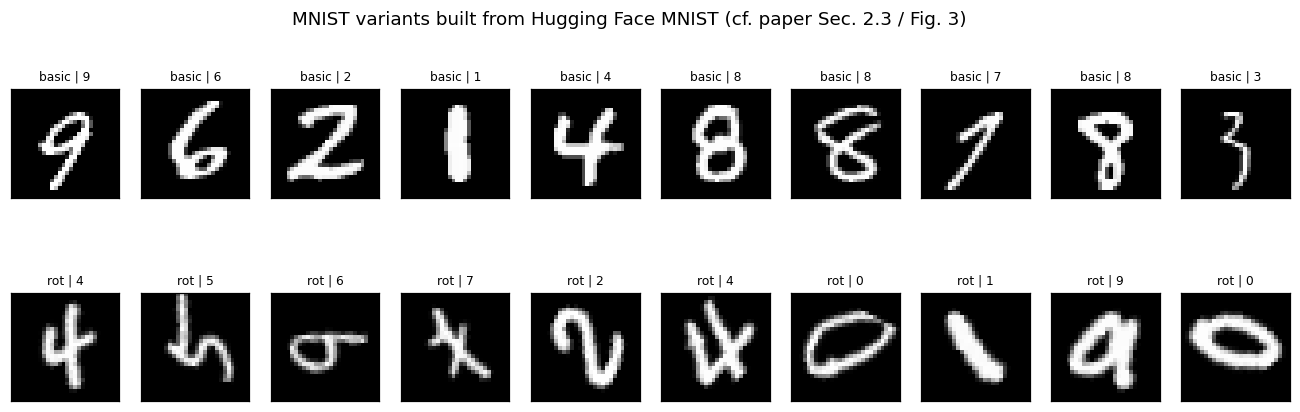

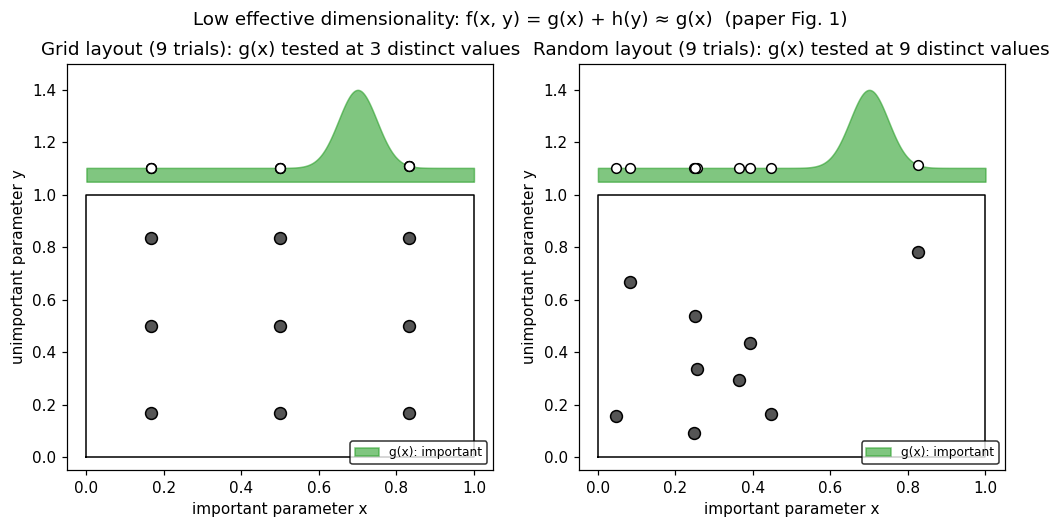

In [11]:

# ---- Figure: sample images (cf. paper Fig. 3) ----------------------------------------------
fig, axes = plt.subplots(len(DATASET_NAMES), 10, figsize=(15, 1.9 * len(DATASET_NAMES) + 0.6))
axes = np.atleast_2d(axes)
for r, name in enumerate(DATASET_NAMES):
    for c in range(10):
        ax = axes[r, c]
        ax.imshow(DATA[name]["images"]["train"][c], cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"{DS_ABBR[name]} | {DATA[name]['labels']['train'][c]}", fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
        style_ax(ax)
fig.suptitle("MNIST variants built from Hugging Face MNIST (cf. paper Sec. 2.3 / Fig. 3)", color="black")
render_inline(fig)

# ---- Figure: Fig. 1 intuition (grid vs random under low effective dimensionality) --------
def g_important(x):
    return 0.15 + 0.85 * np.exp(-((x - 0.7) / 0.07) ** 2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
ill_rng = np.random.default_rng(SEED)
gx = (np.arange(3) + 0.5) / 3
layouts = {"Grid layout": np.array([[a, b] for a in gx for b in gx]),
           "Random layout": ill_rng.uniform(0.02, 0.98, size=(9, 2))}
xs = np.linspace(0, 1, 400)
for ax, (title, pts) in zip(axes, layouts.items()):
    ax.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color="black", lw=1)
    ax.fill_between(xs, 1.05, 1.05 + 0.35 * g_important(xs), color="#2ca02c", alpha=0.6,
                    label="g(x): important")
    ax.scatter(pts[:, 0], pts[:, 1], s=60, color="#555555", edgecolor="black", zorder=3)
    ax.scatter(pts[:, 0], 1.05 + 0.35 * g_important(pts[:, 0]), s=40, facecolor="white",
               edgecolor="black", zorder=4)
    n_distinct = len(np.unique(np.round(pts[:, 0], 6)))
    ax.set_title(f"{title} (9 trials): g(x) tested at {n_distinct} distinct values")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.5)
    ax.set_xlabel("important parameter x")
    ax.set_ylabel("unimportant parameter y")
    ax.legend(loc="lower right", fontsize=8)
    style_ax(ax)
fig.suptitle("Low effective dimensionality: f(x, y) = g(x) + h(y) ≈ g(x)  (paper Fig. 1)", color="black")
render_inline(fig)

## How grid serach works
1. Define the Hyper-Parameteres to tune and list the candidate values
2. Form the cartesian product (The grid)
3. Train and cross-validate our model
4. Extract the optimal configuration parameter set

For a SVM
1. C: (0.1, 1.0, 10.0)
2. Kernel : ("Linear", "RBF)

2. forming the cartesian product:

1.  (C: 0.1, kerenl="linear")
2.  (C: 0.1, kerenl="RBF")
3. (C: 1.0, kerenl="Linear")
4. (C: 1.0, kerenl="RBF")
5. (C: 10.0, kerenl="Linear")
6. (C: 10.0, kerenl="RBF")

3. Train our model on those hyper-parameter set and cross-validate it on our validation dataset

4. Choose the optimal set of the hyper-parameter


If you have 5 hyper-paramters to tune and 5 values as candidate each, then 5^5 = 3125 possible candidates.

if you use 5-fold cross validation then it will be = 15625 model fits

## How the random search works:
1. We define our hyper-prameter distributions
2. Sample and select those hyper-parameter values
3. Train the model and cross-validate it on those validation dataset
4. Extract the optimal configuration hyper-parameters values.


What is the number of model fitted during random search


number of iteration = 50
5 fold cross validation

5 * 50 = 250 model fits (wheater you have 3 paramter to 30 ones it will be  = 250)

In [12]:
# -------------------------------------------------------------------------------------
# 4. HYPER-PARAMETER SPACE Λ: random sampler (Sec. 2.4) and matched grid
# -------------------------------------------------------------------------------------
# this function defines the log-uniform function that samples (draws) uniformley from a uniform dist
def log_uniform(rng, lo, hi):
    """'Drawn exponentially': uniform in the log domain, then exponentiated (footnote 3)."""
    return float(np.exp(rng.uniform(np.log(lo), np.log(hi))))

# this function defines the samples hyper-parameter function
def sample_hparams(rng):
    """One i.i.d. draw λ ~ prior over Λ (Sec. 2.4, no-preprocessing variant)."""
    return {
        "n_hidden": int(round(log_uniform(rng, *HIDDEN_RANGE))), # 18-1024 hidden units
        "activation": str(rng.choice(["sigmoid", "tanh"])),
        "init_dist": str(rng.choice(["uniform", "normal"])), # glort vs he initializer
        "init_heuristic": str(rng.choice(["lecun", "glorot"])),
        "init_mult": float(rng.uniform(*INIT_MULT_RANGE)),
        "seed": int(rng.choice(SEED_CHOICES)), # 0 - 1 - 2
        "batch_size": int(rng.choice(BATCH_CHOICES)), # 20 - 100
        "lr0": log_uniform(rng, *LR_RANGE), # learning rate choice
        "t0": log_uniform(rng, *T0_RANGE),
        "l2": 0.0 if rng.random() < 0.5 else log_uniform(rng, *L2_RANGE), # l2 penalty strength
    }
# this function turn the init into a weight scale (lecun vs glorot)
def init_scale(hp, n_in):
    """Weight-scaling heuristics of Sec. 2.4."""
    if hp["init_heuristic"] == "lecun":
        # using lecun method to multiply our weights by sqrt(n_in)
        return hp["init_mult"] / math.sqrt(n_in)
    # using glorot method for multiplying our weights by
    return math.sqrt(6.0) / math.sqrt(n_in + hp["n_hidden"])

# this function will build the grid (cartesian product) of the grid search method
def build_grid():
    """A grid covering roughly the same domain as the random prior: continuous axes get
    GRID_LEVELS values at evenly spaced log-domain quantiles; categorical axes use both
    values; the remaining hyper-parameters are fixed."""
    # acts a qs variable to use later on to initialize our grid for the grid sarch
    qs = [(i + 1) / (GRID_LEVELS + 1) for i in range(GRID_LEVELS)]

    def q_geo(lo, hi, q):
        # this will return the Q-geomety of the search space for the grid search
        return float(np.exp(np.log(lo) + q * (np.log(hi) - np.log(lo))))

    axes_ = {
        # multiple candidate values for number of hidden units to try out (18-1024)
        "n_hidden": [int(round(q_geo(*HIDDEN_RANGE, q))) for q in qs],

        "activation": ["sigmoid", "tanh"], # activation function choices

        "init_heuristic": ["lecun", "glorot"], # inti method to init our weight scales

        "lr0": [q_geo(*LR_RANGE, q) for q in qs], # learning_rate value

        "t0": [q_geo(*T0_RANGE, q) for q in qs], # init t value

        "l2": [0.0] + [q_geo(*L2_RANGE, (i + 1) / GRID_LEVELS) for i in range(GRID_LEVELS - 1)],
    }
    # these hyper-parameteres will always be the same (fixes, constant)
    fixed = {"init_dist": "uniform", "init_mult": 1.1, "seed": 0, "batch_size": 20}

    keys = list(axes_)
    # reutrn the cartesian product by using itertool.products
    return [dict(fixed, **dict(zip(keys, combo)))
            for combo in itertools.product(*[axes_[k] for k in keys])]


# ---- Encoding of λ for GP/ARD (Sec. 3): the 7 hyper-parameters of Fig. 7, scaled to [0,1] --
ARD_NAMES = ["h.u.", "a.f.", "w.a.", "w.n.", "w.p.", "l.r.", "l.a."]
ARD_LONG = ["n. hidden units", "activation fn.", "initial W algo.", "initial W norm",
            "weight penalty", "learning rate", "learn rate anneal."]
L2_OFF_CODE = L2_RANGE[0] / 10.0

# this function will acts as a gaussian process for searching over our hyper-parameter
def ard_bounds(n_in):
    # weight normalization low value
    wn_lo = min(INIT_MULT_RANGE[0] / math.sqrt(n_in), math.sqrt(6) / math.sqrt(n_in + HIDDEN_RANGE[1]))
    # weight normalization high value
    wn_hi = max(INIT_MULT_RANGE[1] / math.sqrt(n_in), math.sqrt(6) / math.sqrt(n_in + HIDDEN_RANGE[0]))

    return np.array([
        [np.log(HIDDEN_RANGE[0]), np.log(HIDDEN_RANGE[1])],
        [0.0, 1.0], [0.0, 1.0],
        [np.log(wn_lo), np.log(wn_hi)],
        [np.log10(L2_OFF_CODE), np.log10(L2_RANGE[1])],
        [np.log(LR_RANGE[0]), np.log(LR_RANGE[1])],
        [np.log(T0_RANGE[0]), np.log(T0_RANGE[1])],
    ])

# this function define the array of the hyper-parameter we can loop thourhg
def encode_hparams(hp, n_in):
    raw = np.array([
        np.log(hp["n_hidden"]),
        float(hp["activation"] == "tanh"),
        float(hp["init_dist"] == "normal"),
        np.log(init_scale(hp, n_in)),
        np.log10(hp["l2"] if hp["l2"] > 0 else L2_OFF_CODE),
        np.log(hp["lr0"]),
        np.log(hp["t0"]),
    ])

    b = ard_bounds(n_in)
    # limiting the range of the values into (0,1) for those columns
    return np.clip((raw - b[:, 0]) / (b[:, 1] - b[:, 0]), 0.0, 1.0)


def fmt_hp(hp):
    init = f"{hp['init_dist']}/{hp['init_heuristic']}"
    if hp["init_heuristic"] == "lecun":
        init += f"×{hp['init_mult']:.2f}"

    return (f"h.u.={hp['n_hidden']}, act={hp['activation']}, init={init}, "
            f"ε0={hp['lr0']:.4g}, t0={hp['t0']:.3g}, ℓ2={hp['l2']:.2g}, "
            f"batch={hp['batch_size']}, seed={hp['seed']}")


In [13]:
# -------------------------------------------------------------------------------------
# 5. MODEL — single-hidden-layer network, written from first principles (Sec. 2.4)
# -------------------------------------------------------------------------------------
class SingleHiddenLayerNet(nn.Module):
    """p(y | x) = softmax(W2 · act(W1 x + b1) + b2)."""
    def __init__(self, n_in, n_hidden, n_out, activation, init_dist, scale, generator):
        # n_in: 784 number of input pixels
        # n_hidden: number of hidden units (neurons)
        # n_out: number of output units (neurons)
        # activation: sigmoid/tanh activation to use
        # init_dist: out init distribution (glorot or He)
        # scale: (lecun/glorot) scale to scale our weights/biases
        # generator: produce the same numbers using a seed value

        super().__init__()

        # model equation: softmax(W * activation(W * X + b) + b)

        self.activation = activation
        # defining our parameters by hand (manually) nn.Parameter()
        # random, scaled weights (initlized using the empty function in pytorch)
        self.W1 = nn.Parameter(torch.empty(n_hidden, n_in)) # map our inputs to the hidden layer

        self.b1 = nn.Parameter(torch.zeros(n_hidden)) # define our bias vector by using zeros tensor generation
        # mapping our hidden units to the output units (second weights matrix)
        self.W2 = nn.Parameter(torch.zeros(n_out, n_hidden))   # output weights start at zero
        self.b2 = nn.Parameter(torch.zeros(n_out)) # define our bias vector full of zeros (learned)
        # logits (0.1, 0.1, 0.1, 0.1, 0.1) 10/1=P(y|X)
        # The number of trainable parameters grows with n_hidden:
        # n_hidden	Trainable parameters
        # 18 (smallest)	14,320
        # 136 (median of the prior)	108,130
        # 1024 (largest)	814,090

        with torch.no_grad(): # main context manager to disable/turn off our gradient tracking context way
            if init_dist == "uniform": # if we choose to init using uniform dist
                self.W1.uniform_(-1.0, 1.0, generator=generator)
            else:
                self.W1.normal_(0.0, 1.0, generator=generator) # He way of init weights
            self.W1.mul_(scale) # lecun/glorot of scaling the weights by a multiplier
    # define the forward method to define the forward compuation of the neural network
    def forward(self, x):

        # Property	     sigmoid	tanh
        # Output range	 (0, 1)	    (−1, 1)
        # Zero-centred	 no	        yes
        # Maximum slope  0.25	    1.0


        a = x @ self.W1.t() + self.b1 # pre-activation calculation before applying any non-linearity

        h = torch.sigmoid(a) if self.activation == "sigmoid" else torch.tanh(a)

        return h @ self.W2.t() + self.b2 # peform our final output layer (logits)
    # applies the Ridge penlty to weights values to shrink (penalise) them to be smaller (lower)
    def l2_penalty(self):
        # return the sum of the squared weights
        return (self.W1 ** 2).sum() + (self.W2 ** 2).sum()  # reduce larger weights toward lower ones

# annealed learning rate schedule
def annealed_lr(t, eps0, t0):
    # t is the learning rate time step, eps0 the initial learning rate value
    # t0 the epoch at which we start to decay (decrease) the learning rate value
    """Eq. 7:  ε_t = t0 · ε0 / max(t, t0)."""
    return t0 * eps0 / max(t, t0)


In [14]:
# -------------------------------------------------------------------------------------
# 6. TRAINING ONE TRIAL = evaluating Ψ(λ) for one hyper-parameter setting
# -------------------------------------------------------------------------------------
# what are actually recorded during the training/validation loop
HIST_KEYS = ["train_nll", "train_l2", "train_total", "train_acc",
             "val_nll", "val_total", "val_acc", "val_per_class"]

# disable/turn off our gradient tracking method by using python decorator
@torch.no_grad()

# runs on complete pass over an entire validation dataset and evaluates the model on that dataset
def evaluate(model, X, y, l2_coef, n_classes):
    # model instance our model object
    # X our inputs batch
    # y our outputs/targets batch
    # l2_coeff our main penalty strength
    # n_classes number of output classes
    # 10^4 = a large number (positive infinity)
    # -1^4 - a very small tiny number (negative infinity)
    logits = torch.nan_to_num(model(X), nan=0.0, posinf=1e4, neginf=-1e4)
    # turn our logits into probabilities by using log_softmax() (0, 1)
    logp = F.log_softmax(logits, dim=1)

    nll = F.nll_loss(logp, y).item() # compute the loss term on its own
    # this is our l2 penalty strength (convert NaN values into a real-valued number)
    l2_term = l2_coef * torch.nan_to_num(model.l2_penalty(), nan=0.0, posinf=1e12).item()

    probs = logp.exp()

    pred = probs.argmax(dim=1) # greedy choise that can choose the highest possible probablity

    correct = pred == y # boolean tensor (True, False)
    # compute the per-class accuracy value (for every single class one accuracy score)
    per_class = np.array([correct[y == c].float().mean().item() if bool((y == c).any())
                          else np.nan for c in range(n_classes)])

    return {"nll": nll, "l2": l2_term, "total": nll + l2_term,
            "acc": correct.float().mean().item(), "per_class": per_class,
            "probs": probs.cpu().numpy(), "pred": pred.cpu().numpy()}

# this function train one model instance on the full training dataset and records the metrics to plot them
def train_trial(hp, ds_name):
    d = DATA[ds_name] # MNIST_BASTIC, MNIST_ROTATED, MNIST_BACKGROUND_NOISE
    # generate one generator to use it across the trial ()
    gen = torch.Generator().manual_seed(1000 + hp["seed"]) # 1000, 1001, 1002
    # 18-1024 (sigmoid/tanh) (glorot/he) + (lecun/glorot) (gen to use the seed value of)
    model = SingleHiddenLayerNet(d["n_in"], hp["n_hidden"], d["n_classes"], hp["activation"],
                                 hp["init_dist"], init_scale(hp, d["n_in"]), gen).to(DEVICE)
    # create an optimizer to optimize our weights/biases later on
    opt = torch.optim.SGD(model.parameters(), lr=hp["lr0"])
    # 20 - 100
    loader = DataLoader(d["ds"]["train"], batch_size=hp["batch_size"], shuffle=True,
                        generator=torch.Generator().manual_seed(hp["seed"]))

    # set the bookkeeping history dictionary
    hist = {k: [] for k in HIST_KEYS}
    t, diverged = 0, False
    best_err, best_epoch, best_state = float("inf"), 0, None

    for epoch in range(1, EPOCHS + 1): # run one complete trial for 5 epochs

        model.train() # set the model into training mode

        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            t += 1 # increment the t by one every single epoch

            for group in opt.param_groups:                        # Eq. 7 schedule
                group["lr"] = annealed_lr(t, hp["lr0"], hp["t0"])
            # combining both negative log-likelihood + log_softmax()

            nll = F.cross_entropy(model(xb), yb)                  # mean NLL over minibatch
            loss = nll + hp["l2"] * model.l2_penalty()            # + optional ℓ2 penalty
            if not torch.isfinite(loss): # our loss is actaully containing NaN
                diverged = True
                break # not continue training ! (it will waste many steps before the break)

            opt.zero_grad(set_to_none=True) # set the previous gradients to be zero
            loss.backward() # one backward step to compute the gradietn
            opt.step() # do one optimizer step
        # compute the training + validation metrics using the function evaluate
        tr = evaluate(model, d["X"]["train"], d["y"]["train"], hp["l2"], d["n_classes"])
        va = evaluate(model, d["X"]["valid"], d["y"]["valid"], hp["l2"], d["n_classes"])

        for key, val in (("train_nll", tr["nll"]), ("train_l2", tr["l2"]),
                         ("train_total", tr["total"]), ("train_acc", tr["acc"]),
                         ("val_nll", va["nll"]), ("val_total", va["total"]),
                         ("val_acc", va["acc"]), ("val_per_class", va["per_class"])):
            hist[key].append(val)
        # record the best validation score (and also to get the model hyper-parameter at that step)
        val_err = 1.0 - va["acc"] # to get the remaining metrics

        if val_err < best_err:
            best_err, best_epoch = val_err, epoch
            # we have found one better model state value (metrics) and we have to save that milestone
            # save a checkpoint of the model at that specfic step
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if diverged:
            break

        # the validation score is not improve and we have stop early (cut off the training loop)
        if epoch >= ES_MIN_EPOCHS and best_epoch < epoch / 2:     # Sec. 2.4 early-stopping rule
            break

    model.load_state_dict(best_state)


    te = evaluate(model, d["X"]["test"], d["y"]["test"], hp["l2"], d["n_classes"])
    return {
        "hp": hp, "dataset": ds_name, "history": hist, "best_epoch": best_epoch,
        "epochs_run": len(hist["train_nll"]), "diverged": diverged,
        "val_err": best_err, "test_err": 1.0 - te["acc"],
        "test_per_class": te["per_class"], "test_probs": te["probs"], "test_pred": te["pred"],
        "n_params": int(sum(p.numel() for p in model.parameters())),
        "ard_x": encode_hparams(hp, d["n_in"]), "state": best_state,
    }

In [15]:
# -------------------------------------------------------------------------------------
# 7. RUN RANDOM vs GRID SEARCH ON EACH DATA SET
# -------------------------------------------------------------------------------------
GRID_HPS = build_grid()
N_GRID_TRIALS = len(GRID_HPS)
RESULTS, BEST_MODELS = {}, {}
print("\n" + "=" * 80)
print(f"HYPER-PARAMETER SEARCH: {N_RANDOM_TRIALS} random vs {N_GRID_TRIALS} grid trials per data set, "
      f"{EPOCHS} epochs per trial")
print("=" * 80)

for k, name in enumerate(DATASET_NAMES):
    rng = np.random.default_rng(SEED + 7 + k)
    random_hps = [sample_hparams(rng) for _ in range(N_RANDOM_TRIALS)]
    RESULTS[name], BEST_MODELS[name] = {}, {}
    for method, hps in (("random", random_hps), ("grid", GRID_HPS)):
        t_start, trials, best_so_far = time.time(), [], float("inf")
        for i, hp in enumerate(hps):
            res = train_trial(hp, name)
            state = res.pop("state")
            if res["val_err"] < best_so_far:
                best_so_far = res["val_err"]
                BEST_MODELS[name][method] = (hp, state)
            trials.append(res)
            if (i + 1) % 16 == 0 or i + 1 == len(hps):
                print(f"  [{name:14s} | {method:6s}] {i + 1:3d}/{len(hps)} trials | "
                      f"best Ψ_valid = {best_so_far:.4f} | {time.time() - t_start:6.1f}s")
        RESULTS[name][method] = trials



HYPER-PARAMETER SEARCH: 64 random vs 64 grid trials per data set, 5 epochs per trial
  [mnist_basic    | random]  16/64 trials | best Ψ_valid = 0.1175 |   14.1s
  [mnist_basic    | random]  32/64 trials | best Ψ_valid = 0.1175 |   21.3s
  [mnist_basic    | random]  48/64 trials | best Ψ_valid = 0.1150 |   28.9s
  [mnist_basic    | random]  64/64 trials | best Ψ_valid = 0.1050 |   35.3s
  [mnist_basic    | grid  ]  16/64 trials | best Ψ_valid = 0.1250 |   10.5s
  [mnist_basic    | grid  ]  32/64 trials | best Ψ_valid = 0.1100 |   23.0s
  [mnist_basic    | grid  ]  48/64 trials | best Ψ_valid = 0.1100 |   34.8s
  [mnist_basic    | grid  ]  64/64 trials | best Ψ_valid = 0.1075 |   47.9s
  [mnist_rotated  | random]  16/64 trials | best Ψ_valid = 0.4125 |    7.7s
  [mnist_rotated  | random]  32/64 trials | best Ψ_valid = 0.4125 |   14.9s
  [mnist_rotated  | random]  48/64 trials | best Ψ_valid = 0.4125 |   21.6s
  [mnist_rotated  | random]  64/64 trials | best Ψ_valid = 0.4125 |   29.9s
  


RESULTS — test accuracy of the best model (Eq. 5 mean ± Eq. 6 std) and conventional estimate
mnist_basic    random 0.8733 ± 0.0121 | grid 0.8836 ± 0.0103 | best-val test acc R/G = 0.8762/0.8898 | random trials to match grid: None
               difference NOT significant at 95%; 0/64 random trials diverged
               λ̂ random: h.u.=315, act=tanh, init=normal/glorot, ε0=0.3341, t0=20.3, ℓ2=0, batch=100, seed=2
               λ̂ grid  : h.u.=266, act=tanh, init=uniform/lecun×1.10, ε0=0.4642, t0=64.6, ℓ2=0, batch=20, seed=0
mnist_rotated  random 0.5594 ± 0.0210 | grid 0.5038 ± 0.0122 | best-val test acc R/G = 0.5654/0.5098 | random trials to match grid: 32
               difference significant at 95%; 0/64 random trials diverged
               λ̂ random: h.u.=53, act=tanh, init=normal/glorot, ε0=0.6114, t0=138, ℓ2=7.8e-06, batch=20, seed=1
               λ̂ grid  : h.u.=266, act=tanh, init=uniform/glorot, ε0=0.4642, t0=64.6, ℓ2=0, batch=20, seed=0


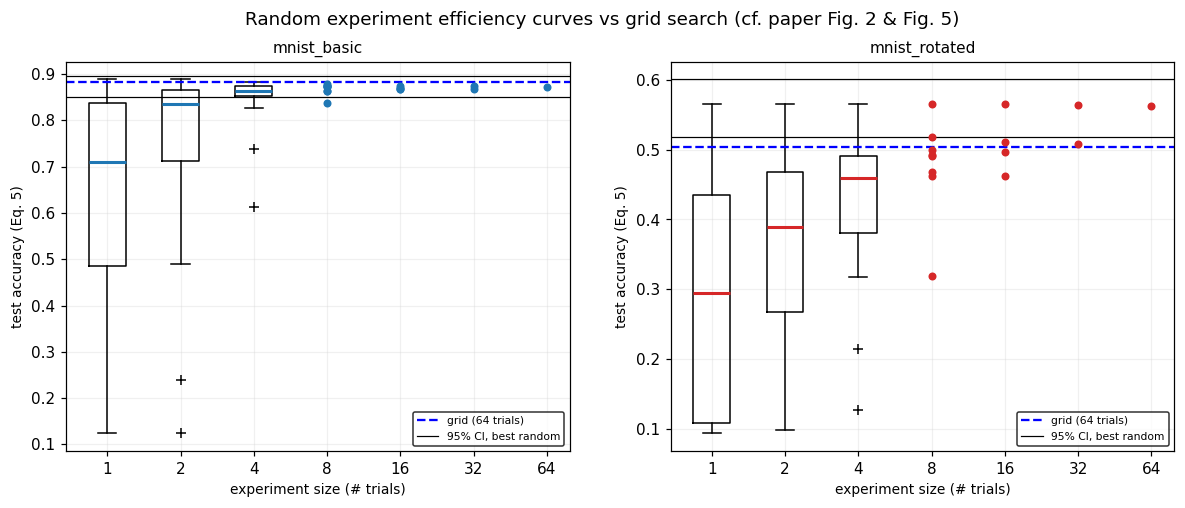

In [34]:
# -------------------------------------------------------------------------------------
# 8. PAPER METRICS: best-model estimate (Eq. 5-6) and efficiency curves (Sec. 2.2)
# -------------------------------------------------------------------------------------
def bernoulli_var(err, n):
    return err * (1.0 - err) / (n - 1)


def best_model_estimate(val_err, test_err, n_valid, n_test, rng, n_sims=N_WEIGHT_SIMS):
    """w_s = P(Z(s) < Z(s') ∀ s'), Z(i) ~ N(Ψ_valid, V_valid);
       μ_z = Σ w_s μ_s (Eq. 5);  σ_z² = Σ w_s (μ_s² + σ_s²) − μ_z² (Eq. 6)."""
    val_err = np.asarray(val_err, dtype=float)
    test_err = np.asarray(test_err, dtype=float)
    S = len(val_err)
    Z = rng.normal(loc=val_err[None, :], scale=np.sqrt(bernoulli_var(val_err, n_valid))[None, :],
                   size=(n_sims, S))
    Z += rng.uniform(0.0, 1e-9, size=Z.shape)
    w = np.bincount(Z.argmin(axis=1), minlength=S) / n_sims
    mu_s = 1.0 - test_err
    var_s = bernoulli_var(test_err, n_test)
    mu_z = float(np.sum(w * mu_s))
    var_z = float(np.sum(w * (mu_s ** 2 + var_s)) - mu_z ** 2)
    return mu_z, math.sqrt(max(var_z, 0.0)), w


def efficiency_curve(val_err, test_err, rng):
    """S i.i.d. trials = N experiments of s trials (sN ≤ S); Eq. 5 score for each."""
    S = len(val_err)
    perm = rng.permutation(S)
    curve = {}
    for s in [2 ** p for p in range(int(math.log2(S)) + 1)]:
        curve[s] = np.array([best_model_estimate(val_err[perm[j * s:(j + 1) * s]],
                                                 test_err[perm[j * s:(j + 1) * s]],
                                                 N_VALID, N_TEST, rng)[0] for j in range(S // s)])
    return curve


ANALYSIS = {}
an_rng = np.random.default_rng(SEED + 99)
for name in DATASET_NAMES:
    R, G = RESULTS[name]["random"], RESULTS[name]["grid"]
    rv, rt = np.array([r["val_err"] for r in R]), np.array([r["test_err"] for r in R])
    gv, gt = np.array([g["val_err"] for g in G]), np.array([g["test_err"] for g in G])
    mu_r, sd_r, _ = best_model_estimate(rv, rt, N_VALID, N_TEST, an_rng)
    mu_g, sd_g, _ = best_model_estimate(gv, gt, N_VALID, N_TEST, an_rng)
    curve = efficiency_curve(rv, rt, an_rng)
    ANALYSIS[name] = {
        "mu_random": mu_r, "sd_random": sd_r, "mu_grid": mu_g, "sd_grid": sd_g, "curve": curve,
        "trials_to_match_grid": next((s for s in sorted(curve) if np.median(curve[s]) >= mu_g), None),
        "best_random": int(np.argmin(rv)), "best_grid": int(np.argmin(gv)),
        "conv_random": 1.0 - rt[np.argmin(rv)], "conv_grid": 1.0 - gt[np.argmin(gv)],
        "n_diverged": int(sum(r["diverged"] for r in R)),
    }

print("\n" + "=" * 100)
print("RESULTS — test accuracy of the best model (Eq. 5 mean ± Eq. 6 std) and conventional estimate")
print("=" * 100)
for name in DATASET_NAMES:
    a = ANALYSIS[name]
    overlap = abs(a["mu_random"] - a["mu_grid"]) <= 1.96 * math.hypot(a["sd_random"], a["sd_grid"])
    print(f"{name:14s} random {a['mu_random']:.4f} ± {a['sd_random']:.4f} | "
          f"grid {a['mu_grid']:.4f} ± {a['sd_grid']:.4f} | best-val test acc R/G = "
          f"{a['conv_random']:.4f}/{a['conv_grid']:.4f} | random trials to match grid: "
          f"{a['trials_to_match_grid']}")
    print(f"{'':14s} difference {'NOT ' if overlap else ''}significant at 95%; "
          f"{a['n_diverged']}/{N_RANDOM_TRIALS} random trials diverged")
    print(f"{'':14s} λ̂ random: {fmt_hp(RESULTS[name]['random'][a['best_random']]['hp'])}")
    print(f"{'':14s} λ̂ grid  : {fmt_hp(RESULTS[name]['grid'][a['best_grid']]['hp'])}")


def plot_efficiency(ax, name, fontsize=9):
    """Box plots for ≥10 experiments per size, scatter otherwise (paper Fig. 2).
    Dashed blue = grid search (Eq. 5); thin black = 95% CI of best random trial (Eq. 6)."""
    a, color = ANALYSIS[name], DS_COLORS[name]
    sizes = sorted(a["curve"])
    pos = np.log2(sizes)
    box_data, box_pos = [], []
    for s, p in zip(sizes, pos):
        v = a["curve"][s]
        if len(v) >= 10:
            box_data.append(v)
            box_pos.append(p)
        else:
            ax.scatter(np.full(len(v), p), v, color=color, s=18, zorder=3)
    if box_data:
        ax.boxplot(box_data, positions=box_pos, widths=0.5, manage_ticks=False,
                   flierprops=dict(marker="+", markeredgecolor="black"),
                   medianprops=dict(color=color, lw=2))
    ax.axhline(a["mu_grid"], ls="--", color="blue", lw=1.5, label=f"grid ({N_GRID_TRIALS} trials)")
    ax.axhline(a["mu_random"] + 1.96 * a["sd_random"], color="black", lw=0.8, label="95% CI, best random")
    ax.axhline(a["mu_random"] - 1.96 * a["sd_random"], color="black", lw=0.8)
    ax.set_xticks(pos)
    ax.set_xticklabels([str(s) for s in sizes])
    ax.set_xlabel("experiment size (# trials)", fontsize=fontsize)
    ax.set_ylabel("test accuracy (Eq. 5)", fontsize=fontsize)
    ax.set_title(name, fontsize=fontsize + 1)
    ax.legend(fontsize=fontsize - 2, loc="lower right")
    ax.grid(alpha=0.3)
    style_ax(ax)


fig, axes = plt.subplots(1, len(DATASET_NAMES), figsize=(6.5 * len(DATASET_NAMES), 4.6))
for ax, name in zip(np.atleast_1d(axes), DATASET_NAMES):
    plot_efficiency(ax, name)
fig.suptitle("Random experiment efficiency curves vs grid search (cf. paper Fig. 2 & Fig. 5)", color="black")
render_inline(fig);

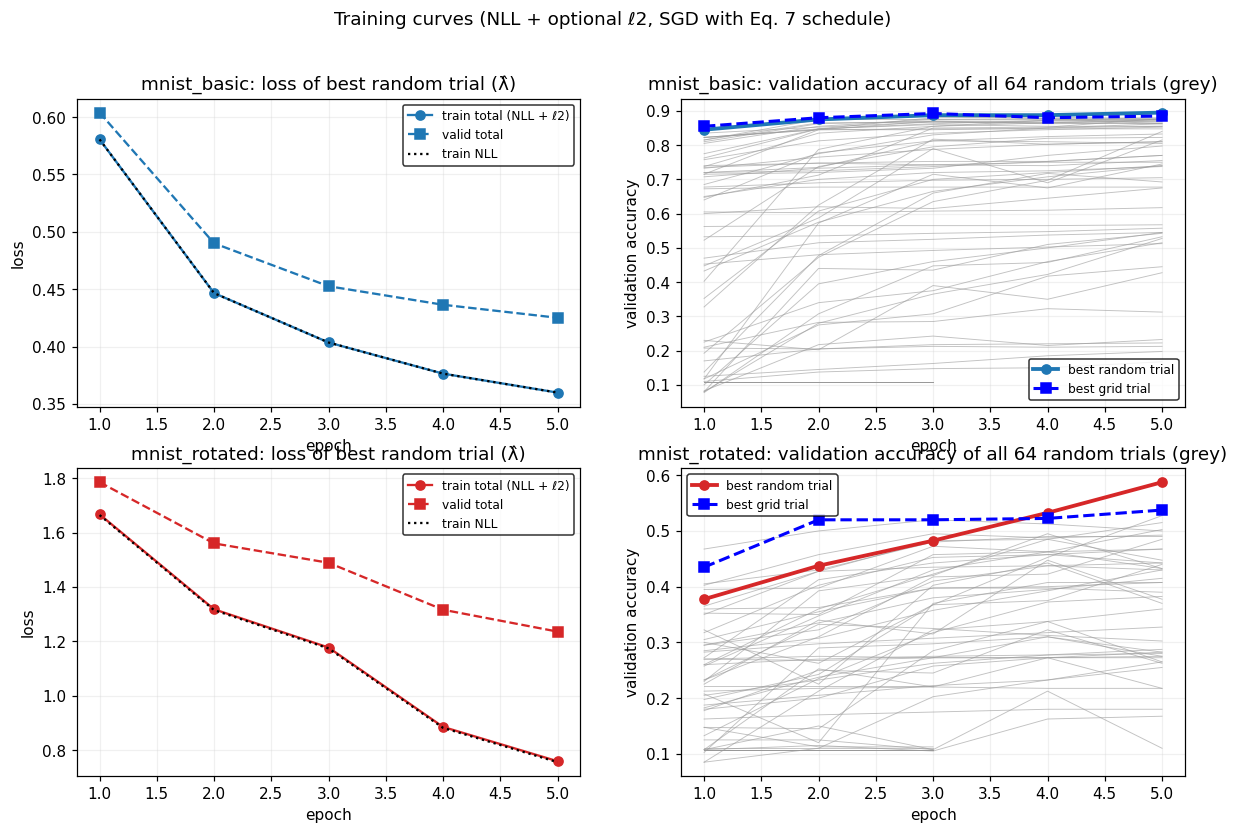

In [35]:
# ---- Figure: standard training curves -------------------------------------------------------
fig, axes = plt.subplots(len(DATASET_NAMES), 2, figsize=(13, 4 * len(DATASET_NAMES)))
axes = np.atleast_2d(axes)
for r, name in enumerate(DATASET_NAMES):
    best = RESULTS[name]["random"][ANALYSIS[name]["best_random"]]
    h = best["history"]
    ep = np.arange(1, best["epochs_run"] + 1)
    ax = axes[r, 0]
    ax.plot(ep, h["train_total"], "o-", color=DS_COLORS[name], label="train total (NLL + ℓ2)")
    ax.plot(ep, h["val_total"], "s--", color=DS_COLORS[name], label="valid total")
    ax.plot(ep, h["train_nll"], ":", color="black", label="train NLL")
    ax.set_title(f"{name}: loss of best random trial (λ̂)")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    style_ax(ax)
    ax = axes[r, 1]
    for tr in RESULTS[name]["random"]:
        ax.plot(np.arange(1, tr["epochs_run"] + 1), tr["history"]["val_acc"], color="#999999",
                lw=0.6, alpha=0.6)
    ax.plot(ep, h["val_acc"], "o-", color=DS_COLORS[name], lw=2.5, label="best random trial")
    gbest = RESULTS[name]["grid"][ANALYSIS[name]["best_grid"]]
    ax.plot(np.arange(1, gbest["epochs_run"] + 1), gbest["history"]["val_acc"], "s--",
            color="blue", lw=2, label="best grid trial")
    ax.set_title(f"{name}: validation accuracy of all {N_RANDOM_TRIALS} random trials (grey)")
    ax.set_xlabel("epoch")
    ax.set_ylabel("validation accuracy")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    style_ax(ax)
fig.suptitle("Training curves (NLL + optional ℓ2, SGD with Eq. 7 schedule)", color="black")
render_inline(fig)


Fitting Gaussian-process ARD models to Ψ (Sec. 3) ...
  [mnist_basic] effective dimension ≈ 3 of 7 | ranking: l.r.=2.64, h.u.=1.03, a.f.=0.91, w.n.=0.57, l.a.=0.42, w.a.=0.23, w.p.=0.19
  [mnist_rotated] effective dimension ≈ 3 of 7 | ranking: l.r.=4.11, a.f.=2.17, l.a.=1.17, w.n.=0.62, h.u.=0.59, w.a.=0.27, w.p.=0.12


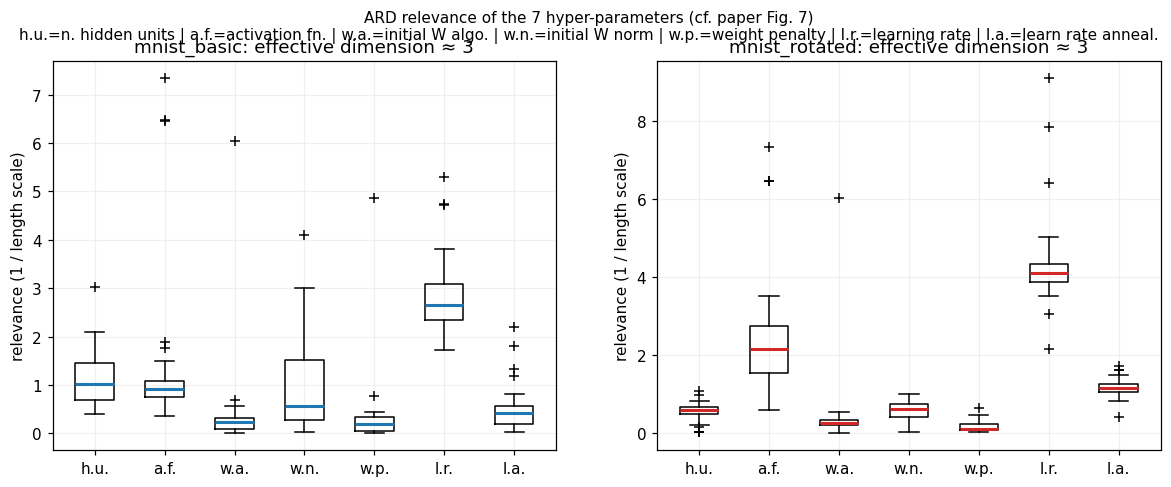

In [32]:
# -------------------------------------------------------------------------------------
# 9. LOW EFFECTIVE DIMENSION OF Ψ: Gaussian-process ARD (Sec. 3, Fig. 7)
# -------------------------------------------------------------------------------------
def fit_ard_gp(X, y, seed, steps=ARD_STEPS):
    """GP with product kernel k(a, b) = Π_j exp(-((a_j - b_j) / l_j)^2). Length scales
    maximise the log marginal likelihood; returns relevance = 1 / l."""
    g = torch.Generator().manual_seed(seed)
    X = torch.as_tensor(X, dtype=torch.float64)
    y = torch.as_tensor(y, dtype=torch.float64)
    y = (y - y.mean()) / (y.std() + 1e-12)
    n, D = X.shape
    log_l = torch.log(torch.rand(D, generator=g, dtype=torch.float64) * 1.9 + 0.1).requires_grad_(True)
    log_sf2 = torch.zeros((), dtype=torch.float64, requires_grad=True)
    log_sn2 = torch.tensor(math.log(0.1), dtype=torch.float64, requires_grad=True)
    opt = torch.optim.Adam([log_l, log_sf2, log_sn2], lr=0.05)
    eye = torch.eye(n, dtype=torch.float64)
    for _ in range(steps):
        opt.zero_grad()
        diff = (X[:, None, :] - X[None, :, :]) / log_l.exp()
        K = log_sf2.exp() * torch.exp(-(diff ** 2).sum(-1)) + (log_sn2.exp() + 1e-6) * eye
        L = torch.linalg.cholesky(K)
        alpha = torch.cholesky_solve(y[:, None], L)
        nlml = (0.5 * (y[:, None] * alpha).sum() + torch.log(torch.diagonal(L)).sum()
                + 0.5 * n * math.log(2 * math.pi))
        nlml.backward()
        opt.step()
        with torch.no_grad():
            log_l.clamp_(math.log(1e-2), math.log(1e3))
            log_sn2.clamp_(min=math.log(1e-4))
            log_sf2.clamp_(-5.0, 5.0)
    return (1.0 / log_l.detach().exp()).numpy()


ARD = {}
print("\nFitting Gaussian-process ARD models to Ψ (Sec. 3) ...")
for k, name in enumerate(DATASET_NAMES):
    R = RESULTS[name]["random"]
    X_ard = np.stack([r["ard_x"] for r in R])
    y_ard = np.array([r["val_err"] for r in R])
    rng = np.random.default_rng(SEED + 500 + k)
    rels = []
    for rep in range(N_ARD_REPEATS):
        idx = rng.choice(len(R), size=int(ARD_SUBSAMPLE * len(R)), replace=False)
        try:
            rels.append(fit_ard_gp(X_ard[idx], y_ard[idx], seed=SEED + rep))
        except RuntimeError:
            continue
    rels = np.array(rels)
    med = np.median(rels, axis=0)
    eff_dim = int(np.sum(med >= 0.25 * med.max()))   # heuristic: ≥ 25% of the top relevance
    ARD[name] = {"rel": rels, "median": med, "eff_dim": eff_dim}
    print(f"  [{name}] effective dimension ≈ {eff_dim} of 7 | ranking: "
          + ", ".join(f"{ARD_NAMES[i]}={med[i]:.2f}" for i in np.argsort(-med)))

fig, axes = plt.subplots(1, len(DATASET_NAMES), figsize=(6.5 * len(DATASET_NAMES), 4.6))
for ax, name in zip(np.atleast_1d(axes), DATASET_NAMES):
    ax.boxplot(ARD[name]["rel"], positions=np.arange(1, 8), widths=0.55, manage_ticks=False,
               flierprops=dict(marker="+", markeredgecolor="black"),
               medianprops=dict(color=DS_COLORS[name], lw=2))
    ax.set_xticks(np.arange(1, 8))
    ax.set_xticklabels(ARD_NAMES)
    ax.set_ylabel("relevance (1 / length scale)")
    ax.set_title(f"{name}: effective dimension ≈ {ARD[name]['eff_dim']}")
    ax.grid(alpha=0.3)
    style_ax(ax)
fig.suptitle("ARD relevance of the 7 hyper-parameters (cf. paper Fig. 7)\n"
             + " | ".join(f"{a}={b}" for a, b in zip(ARD_NAMES, ARD_LONG)), color="black", fontsize=10)
render_inline(fig);



Running the Sec. 4 simulation (1%-volume targets, up to 512 trials) ...
  3-D cube: P(hit) at T≈92: random=0.60, Sobol=0.63, LHS=0.63, grids tested=858
  3-D rect: P(hit) at T≈92: random=0.60, Sobol=0.62, LHS=0.76, grids tested=858
  5-D cube: P(hit) at T≈92: random=0.60, Sobol=0.63, LHS=0.52, grids tested=133
  5-D rect: P(hit) at T≈92: random=0.60, Sobol=0.69, LHS=0.65, grids tested=133


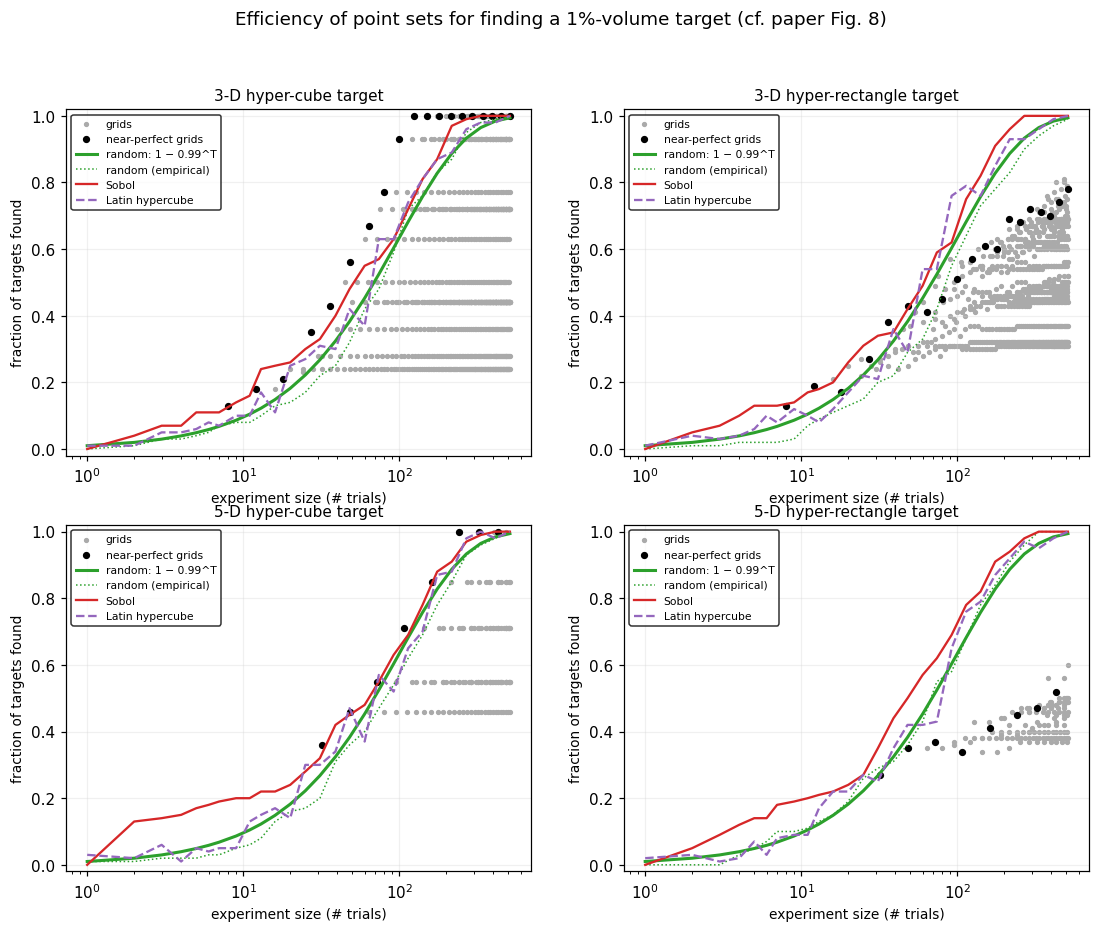

In [18]:
# -------------------------------------------------------------------------------------
# 10. SIMULATION: grid vs random vs low-discrepancy point sets (Sec. 4, Fig. 8)
# -------------------------------------------------------------------------------------
def enumerate_grids(T, d, start=2):
    """All monotonic-resolution grids of exactly T points in d dims (≥ `start` ticks/dim)."""
    if d == 1:
        return [(T,)] if T >= start else []
    out, f = [], start
    while f ** d <= T:
        if T % f == 0:
            for rest in enumerate_grids(T // f, d - 1, f):
                out.append((f,) + rest)
        f += 1
    return out


def grid_points(res):
    mesh = np.meshgrid(*[(np.arange(r) + 0.5) / r for r in res], indexing="ij")
    return np.stack([m.ravel() for m in mesh], axis=1)


def make_targets(n, d, shape, rng):
    """1%-volume axis-aligned target: hyper-cube, or elongated hyper-rectangle."""
    lo, side = np.zeros((n, d)), np.zeros((n, d))
    for i in range(n):
        if shape == "cube":
            s = np.full(d, SIM_TARGET_VOLUME ** (1.0 / d))
        else:
            while True:
                u = rng.uniform(0.0, 1.0, d) + 1e-6
                s = u * (SIM_TARGET_VOLUME / np.prod(u)) ** (1.0 / d)
                if np.all(s < 1.0):
                    break
        side[i] = s
        lo[i] = rng.uniform(0.0, 1.0 - s)
    return lo, side


def contains(points, lo, side):
    P = points if points.ndim == 3 else points[None]
    return ((P >= lo[:, None, :]) & (P <= (lo + side)[:, None, :])).all(axis=-1)


def success_from_sequence(hit, sizes):
    first = np.where(hit.any(axis=1), hit.argmax(axis=1), np.inf)
    return np.array([(first < T).mean() for T in sizes])


def run_simulation(d, shape, rng):
    lo, side = make_targets(SIM_N_TARGETS, d, shape, rng)
    sizes = np.unique(np.round(np.logspace(0, np.log10(SIM_MAX_TRIALS), 30)).astype(int))
    analytic = 1.0 - (1.0 - SIM_TARGET_VOLUME) ** sizes              # 1 − 0.99^T
    rand_emp = success_from_sequence(
        contains(rng.uniform(size=(SIM_N_TARGETS, SIM_MAX_TRIALS, d)), lo, side), sizes)
    sobol = torch.quasirandom.SobolEngine(dimension=d, scramble=False).draw(SIM_MAX_TRIALS)
    sobol_curve = success_from_sequence(contains(sobol.double().numpy(), lo, side), sizes)
    lhs_curve = []
    for T in sizes:
        perms = rng.permuted(np.tile(np.arange(T), (SIM_N_TARGETS, d, 1)), axis=-1)
        pts = np.transpose((perms + rng.uniform(size=perms.shape)) / T, (0, 2, 1))
        lhs_curve.append(contains(pts, lo, side).any(axis=1).mean())
    grids = []
    for T in range(2 ** d, SIM_MAX_TRIALS + 1):
        for res in enumerate_grids(T, d, 2):
            grids.append((T, contains(grid_points(res), lo, side).any(axis=1).mean(),
                          max(res) - min(res) <= 1))
    return {"sizes": sizes, "analytic": analytic, "random": rand_emp, "sobol": sobol_curve,
            "lhs": np.array(lhs_curve), "grids": grids}


print("\nRunning the Sec. 4 simulation (1%-volume targets, up to 512 trials) ...")
SIM = {}
sim_rng = np.random.default_rng(SEED + 4)
for d, shape in ((3, "cube"), (3, "rect"), (5, "cube"), (5, "rect")):
    SIM[(d, shape)] = run_simulation(d, shape, sim_rng)
    s = SIM[(d, shape)]
    i100 = int(np.argmin(np.abs(s["sizes"] - 100)))
    print(f"  {d}-D {shape:4s}: P(hit) at T≈{s['sizes'][i100]}: random={s['analytic'][i100]:.2f}, "
          f"Sobol={s['sobol'][i100]:.2f}, LHS={s['lhs'][i100]:.2f}, grids tested={len(s['grids'])}")


def plot_simulation(ax, key, fontsize=9):
    s = SIM[key]
    g = np.array([(T, r) for T, r, _ in s["grids"]])
    gp = np.array([(T, r) for T, r, perfect in s["grids"] if perfect])
    if len(g):
        ax.scatter(g[:, 0], g[:, 1], s=6, color="#aaaaaa", label="grids", zorder=1)
    if len(gp):
        ax.scatter(gp[:, 0], gp[:, 1], s=14, color="black", label="near-perfect grids", zorder=2)
    ax.plot(s["sizes"], s["analytic"], color="#2ca02c", lw=2, label="random: 1 − 0.99^T")
    ax.plot(s["sizes"], s["random"], color="#2ca02c", lw=1, ls=":", label="random (empirical)")
    ax.plot(s["sizes"], s["sobol"], color="#d62728", lw=1.5, label="Sobol")
    ax.plot(s["sizes"], s["lhs"], color="#9467bd", lw=1.5, ls="--", label="Latin hypercube")
    ax.set_xscale("log")
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("experiment size (# trials)", fontsize=fontsize)
    ax.set_ylabel("fraction of targets found", fontsize=fontsize)
    ax.set_title(f"{key[0]}-D {'hyper-cube' if key[1] == 'cube' else 'hyper-rectangle'} target",
                 fontsize=fontsize + 1)
    ax.legend(fontsize=fontsize - 2, loc="upper left")
    ax.grid(alpha=0.3)
    style_ax(ax)


fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, key in zip(axes.ravel(), [(3, "cube"), (3, "rect"), (5, "cube"), (5, "rect")]):
    plot_simulation(ax, key)
fig.suptitle("Efficiency of point sets for finding a 1%-volume target (cf. paper Fig. 8)", color="black")
render_inline(fig)


QUALITATIVE PREDICTIONS (best random-search model λ̂, test digits)
  [mnist_basic   ] test #0: true digit = 9 | predicted = 4 | confidence = 0.480 ✗
  [mnist_basic   ] test #1: true digit = 2 | predicted = 2 | confidence = 0.967 ✓
  [mnist_basic   ] test #2: true digit = 3 | predicted = 3 | confidence = 0.364 ✓
  [mnist_basic   ] test #3: true digit = 0 | predicted = 0 | confidence = 0.971 ✓
  [mnist_basic   ] test #4: true digit = 2 | predicted = 2 | confidence = 0.988 ✓
  [mnist_basic   ] test #5: true digit = 8 | predicted = 8 | confidence = 0.700 ✓
  [mnist_basic   ] test #6: true digit = 9 | predicted = 9 | confidence = 0.645 ✓
  [mnist_basic   ] test #7: true digit = 0 | predicted = 0 | confidence = 0.797 ✓
  [mnist_basic   ] test #8: true digit = 8 | predicted = 8 | confidence = 0.916 ✓
  [mnist_basic   ] test #9: true digit = 3 | predicted = 3 | confidence = 0.819 ✓
  [mnist_rotated ] test #0: true digit = 9 | predicted = 9 | confidence = 0.534 ✓
  [mnist_rotated ] test #1: tr

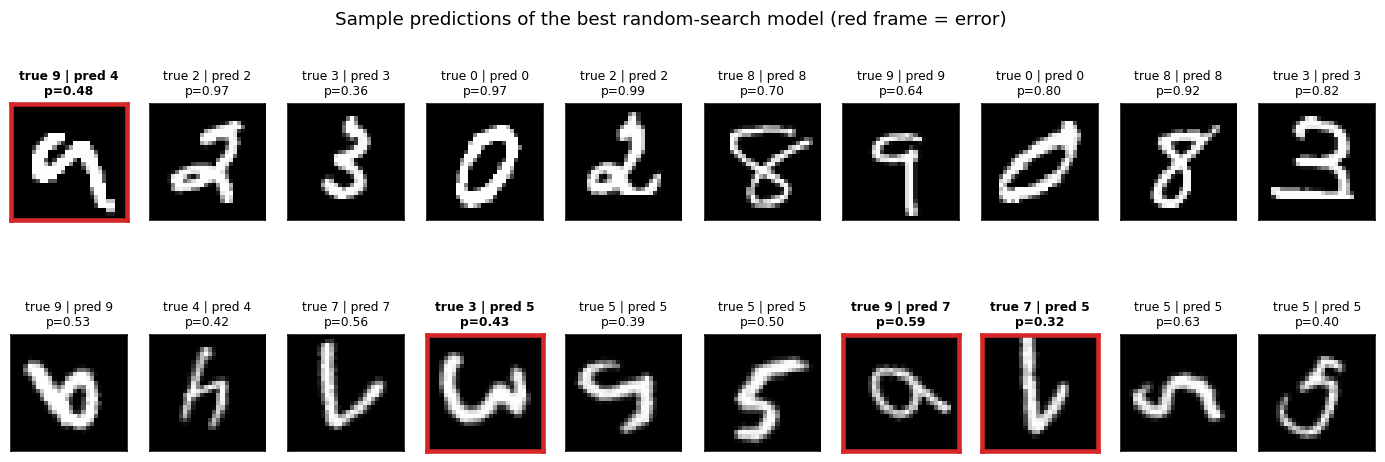

In [19]:
# -------------------------------------------------------------------------------------
# 11. PREDICTION PIPELINE — rebuild the best model λ̂ and classify test digits
# -------------------------------------------------------------------------------------
def build_model_from(hp, state, ds_name):
    d = DATA[ds_name]
    m = SingleHiddenLayerNet(d["n_in"], hp["n_hidden"], d["n_classes"], hp["activation"],
                             hp["init_dist"], 1.0, torch.Generator().manual_seed(0))
    m.load_state_dict(state)
    return m.to(DEVICE).eval()


@torch.no_grad()
def predict(model, images):
    x = torch.as_tensor(images.reshape(len(images), -1), dtype=torch.float32, device=DEVICE)
    probs = F.softmax(torch.nan_to_num(model(x), nan=0.0), dim=1).cpu().numpy()
    return probs.argmax(axis=1), probs.max(axis=1)


print("\n" + "=" * 80 + "\nQUALITATIVE PREDICTIONS (best random-search model λ̂, test digits)\n" + "=" * 80)
N_SHOW = 10
PRED_EXAMPLES = {}
for name in DATASET_NAMES:
    hp, state = BEST_MODELS[name]["random"]
    model = build_model_from(hp, state, name)
    imgs, labels = DATA[name]["images"]["test"][:N_SHOW], DATA[name]["labels"]["test"][:N_SHOW]
    pred, conf = predict(model, imgs)
    PRED_EXAMPLES[name] = (imgs, labels, pred, conf)
    for i in range(N_SHOW):
        print(f"  [{name:14s}] test #{i}: true digit = {labels[i]} | predicted = {pred[i]} | "
              f"confidence = {conf[i]:.3f} {'✓' if pred[i] == labels[i] else '✗'}")

fig, axes = plt.subplots(len(DATASET_NAMES), N_SHOW, figsize=(16, 2.2 * len(DATASET_NAMES) + 0.6))
axes = np.atleast_2d(axes)
for r, name in enumerate(DATASET_NAMES):
    imgs, labels, pred, conf = PRED_EXAMPLES[name]
    for c in range(N_SHOW):
        ax = axes[r, c]
        ax.imshow(imgs[c], cmap="gray", vmin=0, vmax=1)
        ok = pred[c] == labels[c]
        ax.set_title(f"true {labels[c]} | pred {pred[c]}\np={conf[c]:.2f}", fontsize=8,
                     color="black", fontweight="normal" if ok else "bold")
        for sp in ax.spines.values():
            sp.set_color("black" if ok else "#d62728")
            sp.set_linewidth(1 if ok else 3)
        ax.set_xticks([])
        ax.set_yticks([])
fig.suptitle("Sample predictions of the best random-search model (red frame = error)", color="black")
render_inline(fig)


In [20]:
# -------------------------------------------------------------------------------------
# 12. SUMMARY DASHBOARD (final visualisation) — GridSpec 3 x 4, panels A–K
# -------------------------------------------------------------------------------------
#   A total loss of λ̂ | B NLL and ℓ2 components | C accuracy curves | D confusion matrices
#   E per-digit accuracy | F per-digit accuracy by epoch | G confidence | H scorecard
#   I efficiency curves | J ARD relevance | K Sec. 4 simulation (5-D hyper-rectangle)
set_white_theme()

UNITS, E_RANDOM, F_ROWS = [], [], []
CONF_CORRECT, CONF_WRONG = [], []
for name in DATASET_NAMES:
    br = RESULTS[name]["random"][ANALYSIS[name]["best_random"]]
    for c in range(N_CLASSES):
        UNITS.append(f"{DS_ABBR[name]}:{c}")
        E_RANDOM.append(br["test_per_class"][c])
        row = np.full(EPOCHS, np.nan)
        vals = [pc[c] for pc in br["history"]["val_per_class"]]
        row[:len(vals)] = vals
        F_ROWS.append(row)
    conf = br["test_probs"].max(axis=1)
    correct = br["test_pred"] == DATA[name]["labels"]["test"]
    CONF_CORRECT.append(conf[correct])
    CONF_WRONG.append(conf[~correct])
E_RANDOM, F_MAT = np.array(E_RANDOM), np.array(F_ROWS)
CONF_CORRECT, CONF_WRONG = np.concatenate(CONF_CORRECT), np.concatenate(CONF_WRONG)

fig = plt.figure(figsize=(28, 21))
fig.patch.set_facecolor("white")
gs = GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.32)
PANEL_FS = 11


def panel_title(ax, letter, text):
    ax.set_title(f"{letter}. {text}", fontsize=PANEL_FS, fontweight="bold", color="black", loc="left")

<Figure size 2800x2100 with 0 Axes>

In [21]:
# ---- Panel A ---------------------------------------------------------------------------
axA = fig.add_subplot(gs[0, 0])
for name in DATASET_NAMES:
    br = RESULTS[name]["random"][ANALYSIS[name]["best_random"]]
    ep = np.arange(1, br["epochs_run"] + 1)
    axA.plot(ep, br["history"]["train_total"], "o-", color=DS_COLORS[name], label=f"{name} train")
    axA.plot(ep, br["history"]["val_total"], "s--", color=DS_COLORS[name], label=f"{name} valid")
axA.set_xlabel("epoch")
axA.set_ylabel("NLL + ℓ2")
axA.legend(fontsize=8)
axA.grid(alpha=0.3)
panel_title(axA, "A", "Total loss of λ̂ (train / valid)")
style_ax(axA)

<Axes: title={'left': 'A. Total loss of λ̂ (train / valid)'}, xlabel='epoch', ylabel='NLL + ℓ2'>

In [22]:
# ---- Panel B ---------------------------------------------------------------------------
axB = fig.add_subplot(gs[0, 1])
axB2 = axB.twinx()
handles = []
for name in DATASET_NAMES:
    br = RESULTS[name]["random"][ANALYSIS[name]["best_random"]]
    ep = np.arange(1, br["epochs_run"] + 1)
    handles += axB.plot(ep, br["history"]["train_nll"], "o-", color=DS_COLORS[name],
                        label=f"{name}: NLL (left)")
    handles += axB2.plot(ep, br["history"]["train_l2"], "^:", color=DS_COLORS[name],
                         label=f"{name}: ℓ2 term (right, λ={br['hp']['l2']:.1e})")
axB.set_xlabel("epoch")
axB.set_ylabel("train NLL")
axB2.set_ylabel("train ℓ2 penalty term")
axB.legend(handles=handles, fontsize=7, loc="upper right")
axB.grid(alpha=0.3)
panel_title(axB, "B", "Loss components defined in Sec. 2.4")
style_ax(axB)
style_ax(axB2)

<Axes: ylabel='train ℓ2 penalty term'>

In [23]:
# ---- Panel C ---------------------------------------------------------------------------
axC = fig.add_subplot(gs[0, 2])
for name in DATASET_NAMES:
    br = RESULTS[name]["random"][ANALYSIS[name]["best_random"]]
    ep = np.arange(1, br["epochs_run"] + 1)
    axC.plot(ep, br["history"]["train_acc"], "o-", color=DS_COLORS[name], label=f"{name} train")
    axC.plot(ep, br["history"]["val_acc"], "s--", color=DS_COLORS[name], label=f"{name} valid (1 − Ψ)")
axC.set_xlabel("epoch")
axC.set_ylabel("accuracy")
axC.legend(fontsize=8)
axC.grid(alpha=0.3)
panel_title(axC, "C", "Train / validation accuracy of λ̂")
style_ax(axC)

<Axes: title={'left': 'C. Train / validation accuracy of λ̂'}, xlabel='epoch', ylabel='accuracy'>

In [24]:
# ---- Panel D: 10x10 confusion matrices (diagonal annotated) ------------------------------
gsD = GridSpecFromSubplotSpec(1, len(DATASET_NAMES), subplot_spec=gs[0, 3], wspace=0.35)
for j, name in enumerate(DATASET_NAMES):
    ax = fig.add_subplot(gsD[0, j])
    br = RESULTS[name]["random"][ANALYSIS[name]["best_random"]]
    cm = np.zeros((N_CLASSES, N_CLASSES))
    np.add.at(cm, (DATA[name]["labels"]["test"], br["test_pred"]), 1)
    cm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    ax.imshow(cm, cmap=LIGHT_CMAP, vmin=0, vmax=1)
    for c in range(N_CLASSES):
        ax.text(c, c, f"{cm[c, c]:.2f}", ha="center", va="center", color="black", fontsize=5.5)
    ax.set_xticks(range(N_CLASSES))
    ax.set_yticks(range(N_CLASSES))
    ax.tick_params(labelsize=7)
    ax.set_xlabel("predicted digit", fontsize=8)
    ax.set_ylabel("true digit", fontsize=8)
    ax.set_title(name, fontsize=9, color="black")
    style_ax(ax)
    if j == 0:
        ax.text(0.0, 1.15, "D. Normalised confusion (test, λ̂)", transform=ax.transAxes,
                fontsize=PANEL_FS, fontweight="bold", color="black")


In [25]:
# ---- Panel E: per-digit accuracy, random λ̂ (bars) vs grid (diamonds) --------------------
axE = fig.add_subplot(gs[1, 0])
digits = np.arange(N_CLASSES)
width = 0.8 / len(DATASET_NAMES)
for j, name in enumerate(DATASET_NAMES):
    br = RESULTS[name]["random"][ANALYSIS[name]["best_random"]]
    bg = RESULTS[name]["grid"][ANALYSIS[name]["best_grid"]]
    xp = digits + (j - (len(DATASET_NAMES) - 1) / 2) * width
    axE.bar(xp, br["test_per_class"], width=width, color=DS_COLORS[name], alpha=0.55,
            edgecolor="black", label=f"{name}: random λ̂")
    axE.scatter(xp, bg["test_per_class"], marker="D", s=22, color="black", zorder=3,
                label="best grid λ" if j == 0 else None)
axE.set_xticks(digits)
axE.set_xlabel("digit class")
axE.set_ylim(0, 1.05)
axE.set_ylabel("test accuracy")
axE.legend(fontsize=8, loc="lower left")
panel_title(axE, "E", "Per-digit test accuracy")
style_ax(axE)

<Axes: title={'left': 'E. Per-digit test accuracy'}, xlabel='digit class', ylabel='test accuracy'>

In [26]:
# ---- Panel F: per-digit validation accuracy by epoch ------------------------------------
axF = fig.add_subplot(gs[1, 1])
im = axF.imshow(np.ma.masked_invalid(F_MAT), cmap=LIGHT_CMAP, vmin=0, vmax=1, aspect="auto")
for a_ in range(F_MAT.shape[0]):
    for b_ in range(F_MAT.shape[1]):
        txt = "stop" if np.isnan(F_MAT[a_, b_]) else f"{F_MAT[a_, b_]:.2f}"
        axF.text(b_, a_, txt, ha="center", va="center", color="black", fontsize=6)
axF.set_xticks(np.arange(EPOCHS))
axF.set_xticklabels([str(e + 1) for e in range(EPOCHS)])
axF.set_yticks(np.arange(len(UNITS)))
axF.set_yticklabels(UNITS, fontsize=6.5)
axF.set_xlabel("epoch ('stop' = early-stopped)")
cb = fig.colorbar(im, ax=axF, fraction=0.046, pad=0.04)
cb.ax.tick_params(colors="black", labelcolor="black")
cb.outline.set_edgecolor("black")
panel_title(axF, "F", "Per-digit validation accuracy by epoch (λ̂)")
style_ax(axF)

<Axes: title={'left': 'F. Per-digit validation accuracy by epoch (λ̂)'}, xlabel="epoch ('stop' = early-stopped)">

In [27]:
# ---- Panel G -----------------------------------------------------------------------------
axG = fig.add_subplot(gs[1, 2])
bins = np.linspace(0.0, 1.0, 26)
axG.hist(CONF_CORRECT, bins=bins, alpha=0.7, color="#6baed6", edgecolor="black",
         label=f"correct (n={len(CONF_CORRECT)})")
axG.hist(CONF_WRONG, bins=bins, alpha=0.7, color="#fb6a4a", edgecolor="black",
         label=f"incorrect (n={len(CONF_WRONG)})")
axG.set_xlabel("confidence = max softmax probability")
axG.set_ylabel("count (test, all data sets)")
axG.set_yscale("log")
axG.legend(fontsize=8, loc="upper left")
panel_title(axG, "G", "Confidence: correct vs incorrect")
style_ax(axG)


<Axes: title={'left': 'G. Confidence: correct vs incorrect'}, xlabel='confidence = max softmax probability', ylabel='count (test, all data sets)'>

In [28]:
# ---- Panel I -----------------------------------------------------------------------------
gsI = GridSpecFromSubplotSpec(1, len(DATASET_NAMES), subplot_spec=gs[1, 3], wspace=0.4)
for j, name in enumerate(DATASET_NAMES):
    ax = fig.add_subplot(gsI[0, j])
    plot_efficiency(ax, name, fontsize=8)
    if j == 0:
        ax.text(0.0, 1.12, "I. Efficiency curves: random vs grid (Eq. 5)", transform=ax.transAxes,
                fontsize=PANEL_FS, fontweight="bold", color="black")

In [29]:

# ---- Panel J -----------------------------------------------------------------------------
axJ = fig.add_subplot(gs[2, 0])
bw = 0.8 / len(DATASET_NAMES)
for j, name in enumerate(DATASET_NAMES):
    rel = ARD[name]["rel"]
    med = np.median(rel, axis=0)
    q1, q3 = np.percentile(rel, 25, axis=0), np.percentile(rel, 75, axis=0)
    xp = np.arange(7) + (j - (len(DATASET_NAMES) - 1) / 2) * bw
    axJ.bar(xp, med, width=bw, color=DS_COLORS[name], alpha=0.55, edgecolor="black",
            label=f"{name} (eff. dim ≈ {ARD[name]['eff_dim']})")
    axJ.errorbar(xp, med, yerr=[med - q1, q3 - med], fmt="none", ecolor="black", capsize=3)
axJ.set_xticks(np.arange(7))
axJ.set_xticklabels(ARD_NAMES)
axJ.set_ylabel("relevance = 1 / length scale (median, IQR)")
axJ.legend(fontsize=8)
axJ.grid(alpha=0.3, axis="y")
panel_title(axJ, "J", "GP-ARD: which hyper-parameters matter (Sec. 3)")
style_ax(axJ)

<Axes: title={'left': 'J. GP-ARD: which hyper-parameters matter (Sec. 3)'}, ylabel='relevance = 1 / length scale (median, IQR)'>

In [30]:

# ---- Panel K -----------------------------------------------------------------------------
axK = fig.add_subplot(gs[2, 1])
plot_simulation(axK, (5, "rect"), fontsize=9)
panel_title(axK, "K", "Sec. 4 simulation: 5-D elongated target")
style_ax(axK)

<Axes: title={'left': 'K. Sec. 4 simulation: 5-D elongated target', 'center': '5-D hyper-rectangle target'}, xlabel='experiment size (# trials)', ylabel='fraction of targets found'>

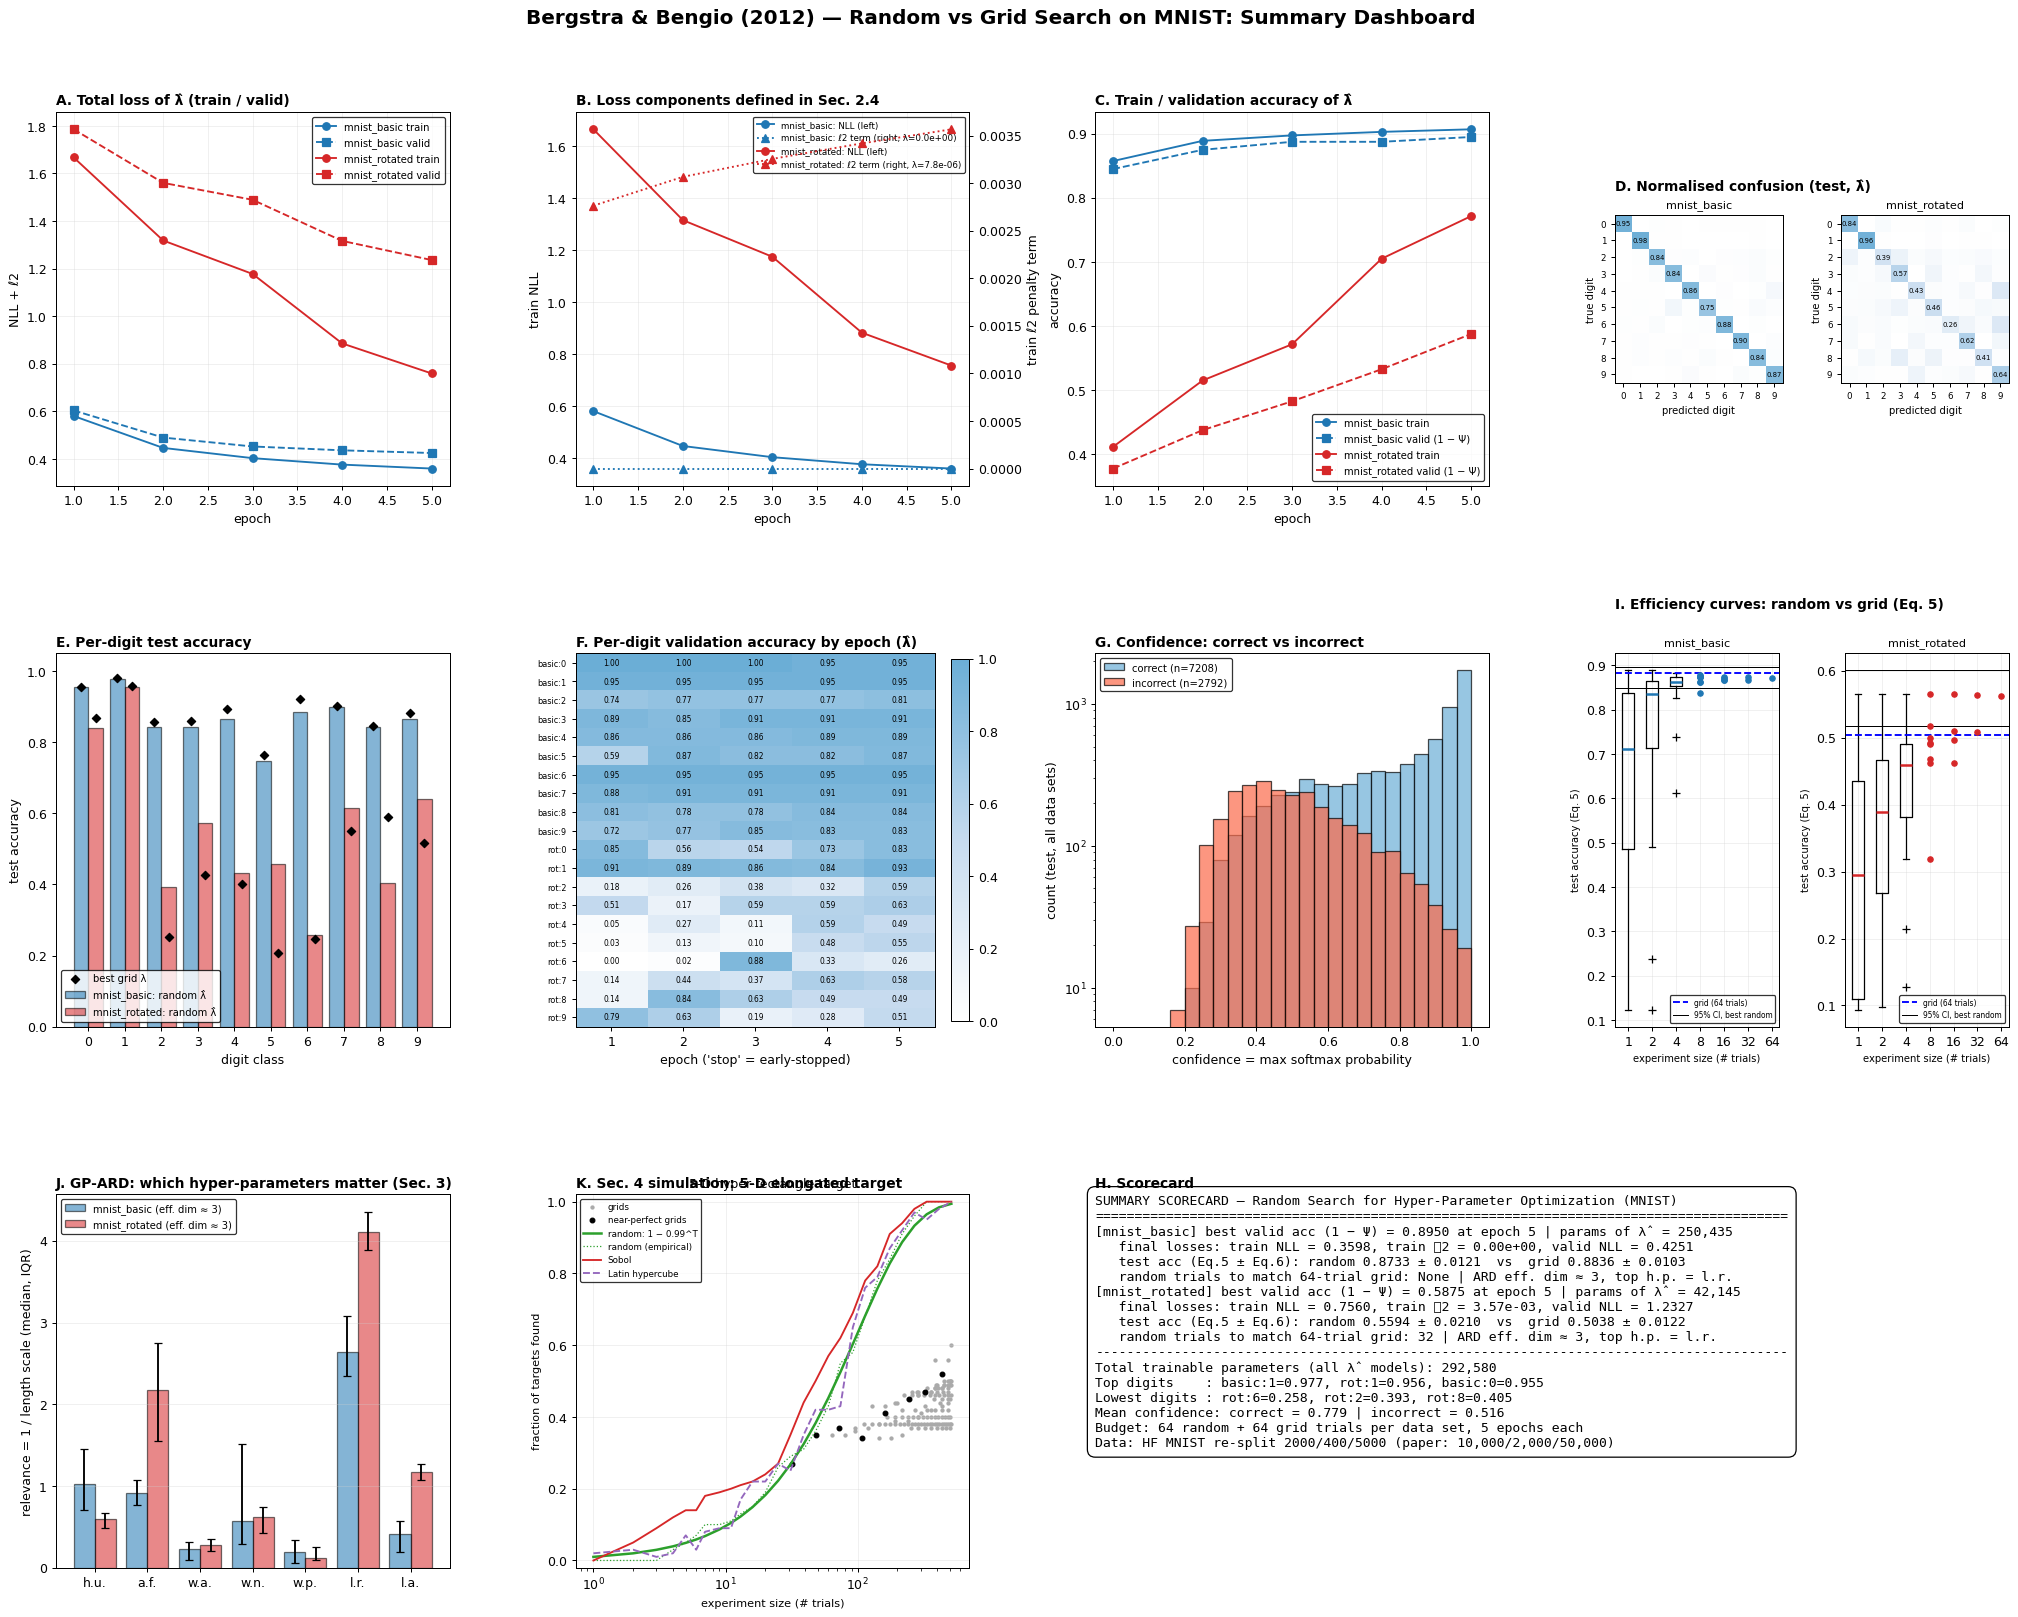

In [31]:

# ---- Panel H: scorecard ------------------------------------------------------------------
axH = fig.add_subplot(gs[2, 2:])
axH.axis("off")
order_units = np.argsort(-E_RANDOM)
lines = ["SUMMARY SCORECARD — Random Search for Hyper-Parameter Optimization (MNIST)", "=" * 88]
total_params = 0
for name in DATASET_NAMES:
    a = ANALYSIS[name]
    br = RESULTS[name]["random"][a["best_random"]]
    total_params += br["n_params"]
    h = br["history"]
    lines += [
        f"[{name}] best valid acc (1 − Ψ) = {1 - br['val_err']:.4f} at epoch {br['best_epoch']}"
        f" | params of λ̂ = {br['n_params']:,}",
        f"   final losses: train NLL = {h['train_nll'][-1]:.4f}, train ℓ2 = {h['train_l2'][-1]:.2e},"
        f" valid NLL = {h['val_nll'][-1]:.4f}",
        f"   test acc (Eq.5 ± Eq.6): random {a['mu_random']:.4f} ± {a['sd_random']:.4f}"
        f"  vs  grid {a['mu_grid']:.4f} ± {a['sd_grid']:.4f}",
        f"   random trials to match {N_GRID_TRIALS}-trial grid: {a['trials_to_match_grid']}"
        f" | ARD eff. dim ≈ {ARD[name]['eff_dim']}, top h.p. = "
        f"{ARD_NAMES[int(np.argmax(ARD[name]['median']))]}",
    ]
lines += [
    "-" * 88,
    f"Total trainable parameters (all λ̂ models): {total_params:,}",
    "Top digits    : " + ", ".join(f"{UNITS[i]}={E_RANDOM[i]:.3f}" for i in order_units[:3]),
    "Lowest digits : " + ", ".join(f"{UNITS[i]}={E_RANDOM[i]:.3f}" for i in order_units[::-1][:3]),
    f"Mean confidence: correct = {CONF_CORRECT.mean():.3f} | incorrect = "
    + (f"{CONF_WRONG.mean():.3f}" if len(CONF_WRONG) else "n/a (no errors)"),
    f"Budget: {N_RANDOM_TRIALS} random + {N_GRID_TRIALS} grid trials per data set, {EPOCHS} epochs each",
    f"Data: HF MNIST re-split {N_TRAIN}/{N_VALID}/{N_TEST} (paper: 10,000/2,000/50,000)",
]
axH.text(0.0, 1.0, "\n".join(lines), transform=axH.transAxes, va="top", ha="left",
         family="monospace", fontsize=10.5, color="black",
         bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="black"))
panel_title(axH, "H", "Scorecard")

fig.suptitle("Bergstra & Bengio (2012) — Random vs Grid Search on MNIST: Summary Dashboard",
             fontsize=16, fontweight="bold", color="black", y=0.935)

buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=90, bbox_inches="tight", facecolor="white")
buf.seek(0)
plt.close(fig)
display(IPImage(data=buf.read()))